In [15]:
import numpy as np
import pandas as pd
from dataclasses import dataclass
from typing import Optional,Literal, Dict, Any

from dataclasses import dataclass, field
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

# Setup

In [16]:
@dataclass
class BSParams:
    r_annual_cc: float
    sigma_annual: float
    s0: float
    s0_date: Optional[pd.Timestamp]

# =========================
# 2) Load index levels from Excel (Col A date, Col B level)
# =========================
def load_index_series_AB(
    xlsx_path: str,
    sheet_name: Optional[str] = None,
) -> pd.Series:
    """
    Đọc time series level của indice từ Excel:
      - Cột A (col 0): Date (từ hàng 2)
      - Cột B (col 1): Index level (từ hàng 2)

    Output:
      pd.Series with DatetimeIndex (date) and float values (level), sorted asc.
    """
    df = pd.read_excel(
        xlsx_path,
        sheet_name=sheet_name if sheet_name is not None else 0,
        header=0,          # hàng 1 là header, data từ hàng 2
        usecols="A:B"      # chỉ lấy cột A,B
    )

    date_col = df.columns[0]
    level_col = df.columns[1]

    # parse date
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")

    # parse level (handle French formats: "1 234,56")
    lvl = (
        df[level_col]
        .astype(str)
        .str.replace(" ", "", regex=False)
        .str.replace(",", ".", regex=False)
    )
    df[level_col] = pd.to_numeric(lvl, errors="coerce")

    s = (
        df[[date_col, level_col]]
        .dropna()
        .drop_duplicates(subset=date_col)
        .set_index(date_col)[level_col]
        .sort_index()
    )

    if s.empty:
        raise ValueError("Series rỗng sau khi đọc/clean. Check sheet_name và dữ liệu cột A,B.")

    if (s <= 0).any():
        raise ValueError("Có giá trị level <= 0, không phù hợp cho log-return/GBM.")

    return s


def estimate_sigma_from_history(levels: pd.Series, day_count: int = 365) -> float:
    """sigma_annual = std(log-return daily) * sqrt(day_count)"""
    s = levels.sort_index()
    logrets = np.log(s / s.shift(1)).dropna()
    return float(logrets.std(ddof=1) * np.sqrt(day_count))


def get_s0(
    levels: pd.Series,
    start_date: str,
    default_s0: float = 1000.0,
    use_real_if_available: bool = False,
) -> tuple[float, Optional[pd.Timestamp]]:
    """Chọn S0: default hoặc lấy đúng level tại start_date nếu có."""
    if not use_real_if_available:
        return float(default_s0), None

    d = pd.Timestamp(start_date)
    if d in levels.index:
        return float(levels.loc[d]), d
    return float(default_s0), None


def build_bs_params_simple(
    levels: pd.Series,
    start_date: str,
    r_neutre_annual_cc: float,
    day_count: int = 365,
    s0_default: float = 1000.0,
    use_real_s0: bool = False,
) -> BSParams:
    """
    Build params đơn giản:
      - sigma: từ dữ liệu quá khứ
      - r_cc: = r_neutre (bạn truyền vào)
      - s0: default hoặc lấy level thật tại start_date nếu có
    """
    s0, s0_date = get_s0(
        levels,
        start_date=start_date,
        default_s0=s0_default,
        use_real_if_available=use_real_s0,
    )

    sigma = estimate_sigma_from_history(levels, day_count=day_count)

    return BSParams(
        r_annual_cc=float(r_neutre_annual_cc),
        sigma_annual=float(sigma),
        s0=float(s0),
        s0_date=s0_date,
    )


def simulate_gbm_monthly(
    s0: float,
    r_annual_cc: float,
    sigma_annual: float,
    start_date: str,
    n_months: int,
    n_sims: int,
    seed: Optional[int] = 42,
) -> pd.DataFrame:
    """GBM monthly simulation, output scenario x dates."""
    rng = np.random.default_rng(seed)

    dt = 1.0 / 12.0
    dates = pd.date_range(start=pd.Timestamp(start_date), periods=n_months + 1, freq="M")

    Z = rng.standard_normal(size=(n_months, n_sims))
    drift = (r_annual_cc - 0.5 * sigma_annual**2) * dt
    diffusion = sigma_annual * np.sqrt(dt) * Z

    log_paths = np.vstack([np.zeros((1, n_sims)), np.cumsum(drift + diffusion, axis=0)])
    paths = s0 * np.exp(log_paths)

    df = pd.DataFrame(paths.T, index=np.arange(1, n_sims + 1), columns=dates)
    df.index.name = "scenario"
    return df


In [17]:
DecrementMode = Literal["flat", "cum"]

def decrement_paths(
    df: pd.DataFrame,
    decrement_value: float = 50.0,   # 50 points per year
    periods_per_year: int = 12,      # monthly
    mode: DecrementMode = "cum",     # với logic bạn nêu: dùng "cum"
) -> pd.DataFrame:
    """
    Linear decrement per period with cumulative option.

    Your target behavior (mode="cum", monthly):
      col0 (t0): 0
      col1:  -50/12
      col2:  -2*50/12
      ...
      colk:  -k*50/12

    mode:
      - "flat": subtract 50/12 mỗi kỳ (không tích lũy)
      - "cum" : subtract k*(50/12) (tích lũy theo số kỳ)
    """
    df_dec = df.copy()

    # ensure datetime columns + sort
    cols = pd.to_datetime(df_dec.columns)
    order = np.argsort(cols.values)
    df_dec = df_dec.iloc[:, order]

    n_cols = df_dec.shape[1]
    if n_cols == 0:
        return df_dec

    per_period = float(decrement_value) / float(periods_per_year)  # 50/12

    # k = 0,1,2,...,n_cols-1 where col0 is t0
    k = np.arange(n_cols, dtype=float)

    if mode == "flat":
        decrements = per_period * (k > 0)          # col0=0, các cột sau trừ 50/12
    elif mode == "cum":
        decrements = per_period * k                # col0=0, col1=1*50/12, col2=2*50/12,...
    else:
        raise ValueError("mode must be 'flat' or 'cum'")

    df_dec.iloc[:, :] = df_dec.values - decrements
    return df_dec


In [18]:
FreqSortie = Literal["mensuelle", "trimestrielle","semestrielle", "annuelle"]

def _freq_to_months(freq_sortie: FreqSortie) -> int:
    if freq_sortie == "mensuelle":
        return 1
    if freq_sortie == "trimestrielle":
        return 3
    if freq_sortie == "semestrielle":
        return 6
    if freq_sortie == "annuelle":
        return 12
    raise ValueError("freq_sortie phải là 'mensuelle', 'trimestrielle', hoặc 'annuelle'.")

def _map_to_next_grid_dates(theo_dates: list[pd.Timestamp], grid: pd.DatetimeIndex) -> list[pd.Timestamp]:
    """
    Map each theoretical date to the first available grid date >= theoretical date.
    Drop dates that cannot be mapped (beyond last grid date).
    """
    mapped = []
    for d in theo_dates:
        pos = grid.searchsorted(d, side="left")
        if pos < len(grid):
            mapped.append(grid[pos])
    return mapped

In [19]:


def Payoff(
    paths: pd.DataFrame,
    date_debut: str | pd.Timestamp,        # ngày phát hành (issue date)
    s_ref: float,                          # mốc ref để xét barrières (1000)
    barriere_sortie_anticipe: float,
    barriere_sortie_maturite: float,
    barriere_protection: float,
    premiere_annee_sortie: int,            # ex: 5 (année 5)
    freq_sortie: FreqSortie,               # mensuelle/trimestrielle/annuelle
    coupon_par_periode: float,
    annee_finale: int,                     # maturity (tính từ date_debut)
    day_count: int = 365,
) -> pd.DataFrame:
    """
    Payoff SAF định giá tại valuation date = cột đầu của `paths`.

    - paths: mô phỏng từ valuation_date (col0) tới tương lai (monthly grid)
    - Lịch observation + maturity được xây theo date_debut (anniversaire),
      rồi map về grid bằng 'next available date'.
    - Barrière xét theo ratio = S_t / S_ref (S_ref cố định).
    - Coupon count (Nb_periodes_total) tính theo số kỳ từ date_debut tới ngày observation lý thuyết.
    """
    if paths.shape[1] < 2:
        raise ValueError("paths phải có ít nhất 2 cột ngày (valuation date + future).")

    df = paths.copy()
    df.columns = pd.to_datetime(df.columns)
    df = df.loc[:, sorted(df.columns)]
    grid_dates = pd.DatetimeIndex(df.columns)

    scenarios = df.index

    # valuation_date là cột đầu của grid
    valuation_date = grid_dates[0]

    # issue date
    date_debut = pd.to_datetime(date_debut)

    # S0 tại valuation_date (theo scenario)
    S0_valuation = df.iloc[:, 0].astype(float)

    step_months = _freq_to_months(freq_sortie)

    # --- Build theoretical observation schedule (anniversary-based) ---
    start_obs_theo = date_debut + pd.DateOffset(years=premiere_annee_sortie)
    maturity_theo = date_debut + pd.DateOffset(years=annee_finale)

    # Observation theoretical dates: start_obs_theo, then +step_months until maturity_theo (inclusive if aligns)
    theo_obs_dates = []
    d = start_obs_theo
    # safeguard to avoid infinite loop
    max_iter = 1000
    it = 0
    while d <= maturity_theo and it < max_iter:
        theo_obs_dates.append(d)
        d = d + pd.DateOffset(months=step_months)
        it += 1
    if it >= max_iter:
        raise RuntimeError("Loop quá dài khi tạo theo_obs_dates. Check inputs.")

    # Keep only obs after valuation_date (mid-life valuation)
    theo_obs_dates = [d for d in theo_obs_dates if d > valuation_date]

    # --- Map theoretical obs dates to simulation grid (next available month-end) ---
    obs_dates_grid = _map_to_next_grid_dates(theo_obs_dates, grid_dates)

    # Maturity date in grid: map maturity_theo to next grid date
    maturity_date_grid_list = _map_to_next_grid_dates([maturity_theo], grid_dates)
    if len(maturity_date_grid_list) == 0:
        raise ValueError("Grid không đủ dài để tới maturity_theo. Tăng n_months simulation.")
    maturity_date_grid = maturity_date_grid_list[0]

    # Ensure we don't observe past maturity in grid
    obs_dates_grid = [d for d in obs_dates_grid if d <= maturity_date_grid]

    # --- Compute period count (coupon count) on THEORETICAL schedule ---
    # For each theoretical obs date d_theo = date_debut + k*step_months, then k_total = k
    # Here months_diff is computed by year/month. Since d_theo is built by DateOffset(months=step_months),
    # it is consistent.
    def k_total_from_theo(d_theo: pd.Timestamp) -> int:
        months_diff = (d_theo.year - date_debut.year) * 12 + (d_theo.month - date_debut.month)
        return int(months_diff // step_months)

    # Build k_total list aligned with obs_dates_grid via theo_obs_dates (same length before mapping drop)
    # Mapping may drop some late theo dates if grid ends early, so we rebuild pairs carefully.
    theo_to_grid_pairs = []
    for d_theo in theo_obs_dates:
        pos = grid_dates.searchsorted(d_theo, side="left")
        if pos < len(grid_dates):
            d_grid = grid_dates[pos]
            if d_grid <= maturity_date_grid:
                theo_to_grid_pairs.append((d_theo, d_grid))

    # If multiple theo map to same grid date (rare but possible), keep first (earliest theo)
    # because autocall should be evaluated at earliest observation.
    seen = set()
    pairs_unique = []
    for d_theo, d_grid in theo_to_grid_pairs:
        if d_grid not in seen:
            pairs_unique.append((d_theo, d_grid))
            seen.add(d_grid)

    # --- Autocall search on mapped grid dates ---
    exit_date = pd.Series(maturity_date_grid, index=scenarios, dtype="datetime64[ns]")
    called = pd.Series(False, index=scenarios)
    nb_periodes_total = pd.Series(index=scenarios, dtype=int)

    # Default: not called -> maturity k_total at maturity_theo
    k_total_maturity = k_total_from_theo(maturity_theo)
    nb_periodes_total.loc[:] = k_total_maturity

    for d_theo, d_grid in pairs_unique:
        if called.all():
            break

        st = df[d_grid].astype(float)
        ratio = (st / float(s_ref)).astype(float)

        hit = (ratio >= barriere_sortie_anticipe) & (~called)
        if hit.any():
            exit_date.loc[hit] = d_grid
            nb_periodes_total.loc[hit] = k_total_from_theo(d_theo)
            called.loc[hit] = True

    # --- Compute payoff at exit ---
    payoff = pd.Series(index=scenarios, dtype=float)

    # ratio at maturity (grid)
    sT = df[maturity_date_grid].astype(float)
    rT = (sT / float(s_ref)).astype(float)

    # Called payoff
    payoff.loc[called] = float(s_ref) * (
        1.0 + coupon_par_periode * nb_periodes_total.loc[called].astype(float)
    )

    not_called = ~called

    # Not called payoff at maturity
    case1 = (rT >= barriere_sortie_maturite) & not_called
    payoff.loc[case1] = float(s_ref) * (
        1.0 + coupon_par_periode * nb_periodes_total.loc[case1].astype(float)
    )

    case2 = (rT >= barriere_protection) & (rT < barriere_sortie_maturite) & not_called
    payoff.loc[case2] = float(s_ref)

    case3 = (rT < barriere_protection) & not_called
    payoff.loc[case3] = float(s_ref) * rT.loc[case3].astype(float)  # = S_T

    # ratio_sortie để debug/analyse
    ratio_sortie = pd.Series(index=scenarios, dtype=float)
    # Called: ratio tại exit_date (grid)
    for d_grid in exit_date.unique():
        mask = (exit_date == d_grid)
        st = df.loc[mask, d_grid].astype(float)
        ratio_sortie.loc[mask] = (st / float(s_ref)).values
    # (đã bao phủ cả called và not_called)

    # T year fraction (discount từ valuation_date)
    T = (pd.to_datetime(exit_date) - pd.to_datetime(valuation_date)).dt.days.astype(float) / float(day_count)

    pay_tbl = pd.DataFrame({
    "Date_simulation": valuation_date,
    "Date_debut": date_debut,
    "S0_simulation": S0_valuation.values,
    "S_ref": float(s_ref),
    "Date_sortie": exit_date.values,
    "Ratio_sortie_S_sur_Sref": ratio_sortie.values,
    "Nb_periodes_total": nb_periodes_total.values,
    "Payoff": payoff.values,
    "Called": called.values,
    }, index=scenarios)

    return pay_tbl


In [20]:
from typing import Literal, Tuple

Compounding = Literal["annual", "cc"]

def VM(
    payoff_table: pd.DataFrame,
    courbe_taux: pd.DataFrame,
    date_valuation: str | pd.Timestamp,
    col_year: str = "Year",
    col_taux: str = "Taux",
    compounding: Compounding = "annual",
    day_count: int = 365,
) -> Tuple[pd.DataFrame, float]:
    """
    Compute expected value at a chosen valuation date.

    Rules:
    - If Date_sortie <= date_valuation: PV = 0 (contract already terminated)
    - Else: discount Payoff from Date_sortie back to date_valuation
    """
    tbl = payoff_table.copy()
    date_valuation = pd.to_datetime(date_valuation)

    curve = courbe_taux[[col_year, col_taux]].copy().dropna()
    curve[col_year] = curve[col_year].astype(float)
    curve[col_taux] = curve[col_taux].astype(float)
    curve = curve.sort_values(col_year)

    x = curve[col_year].values
    y = curve[col_taux].values

    exit_dates = pd.to_datetime(tbl["Date_sortie"])
    payoff = tbl["Payoff"].astype(float).values

    T = (exit_dates - date_valuation).dt.days.astype(float) / float(day_count)

    alive = T > 0
    T_pos = np.where(alive, T, 0.0)

    T_clip = np.clip(T_pos, x.min(), x.max())
    z = np.interp(T_clip, x, y)

    if compounding == "annual":
        df = np.where(alive, 1.0 / np.power(1.0 + z, T_pos), 0.0)
    elif compounding == "cc":
        df = np.where(alive, np.exp(-z * T_pos), 0.0)
    else:
        raise ValueError("compounding must be 'annual' or 'cc'.")

    pv = np.where(alive, payoff * df, 0.0)

    tbl["Date_valuation"] = date_valuation
    tbl["T_en_annees"] = T
    tbl["Alive_at_valuation"] = alive
    tbl["Zero_rate_interp"] = np.where(alive, z, np.nan)
    tbl["Facteur_actualisation"] = df
    tbl["PV"] = pv

    vm = float(np.mean(pv))
    return tbl, vm

# Main


In [21]:
import os
# =========================
# 8) Example usage
# =========================
if __name__ == "__main__":


    xlsx = "Data.xlsx"

    r_neutre_cc = 0.0691009521484375
    levels = load_index_series_AB(xlsx,sheet_name="Data")
    taux_df = pd.read_excel(xlsx,sheet_name="Taux")

    params = build_bs_params_simple(
        levels=levels,
        start_date="2025-12-31",
        r_neutre_annual_cc=r_neutre_cc,
        s0_default=1354.74
 ,

        use_real_s0=False,
    )

    paths = simulate_gbm_monthly(
        s0=params.s0,
        r_annual_cc=params.r_annual_cc,
        # sigma_annual=params.sigma_annual,
        sigma_annual = 0.2662818460057182,
        start_date="2025-12-31",
        n_months=145,
        n_sims=10_000,
        seed=42,
    )

    path_decrement = decrement_paths(paths, decrement_value=50, mode = 'cum')


/tmp/ipykernel_7627/209936294.py:129: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(start=pd.Timestamp(start_date), periods=n_months + 1, freq="M")


In [22]:
pay_tbl = Payoff(
    paths=path_decrement,              # paths mô phỏng từ 31/12/2025 (đã decrement)
    date_debut="2021-08-13",           # ngày phát hành thật
    s_ref=1000.0,
    barriere_sortie_anticipe=0.83,
    barriere_sortie_maturite=0.83,
    barriere_protection=0.5,
    premiere_annee_sortie=5,           # Itineraire: année 5
    freq_sortie="annuelle",
    coupon_par_periode=0.05,
    annee_finale=8,
)

In [23]:
pay_tbl

,Date_simulation,Date_debut,S0_simulation,S_ref,Date_sortie,Ratio_sortie_S_sur_Sref,Nb_periodes_total,Payoff,Called
scenario,,,,,,,,,
1,2025-12-31,2021-08-13,1354.74,1000.0,2026-08-31,1.037891,5.0,1250.0,True
2,2025-12-31,2021-08-13,1354.74,1000.0,2026-08-31,1.149845,5.0,1250.0,True
3,2025-12-31,2021-08-13,1354.74,1000.0,2026-08-31,1.332980,5.0,1250.0,True
4,2025-12-31,2021-08-13,1354.74,1000.0,2026-08-31,1.046806,5.0,1250.0,True
5,2025-12-31,2021-08-13,1354.74,1000.0,2026-08-31,1.000047,5.0,1250.0,True
...,...,...,...,...,...,...,...,...,...
9996,2025-12-31,2021-08-13,1354.74,1000.0,2026-08-31,1.864512,5.0,1250.0,True
9997,2025-12-31,2021-08-13,1354.74,1000.0,2026-08-31,1.479808,5.0,1250.0,True
9998,2025-12-31,2021-08-13,1354.74,1000.0,2026-08-31,1.757374,5.0,1250.0,True


In [24]:
pv0_tbl, vm0 = VM(
    payoff_table=pay_tbl,
    courbe_taux=taux_df,
    date_valuation="2025-12-31",
    compounding="annual",
)

In [25]:
vm0

1227.741220324525

In [26]:
pv1_tbl, vm1 = VM(
    payoff_table=pay_tbl,
    courbe_taux=taux_df,
    date_valuation="2026-12-31",
    compounding="annual",
)

In [27]:
vm1

14.03379867043221

In [28]:
pv1_tbl

,Date_simulation,Date_debut,S0_simulation,S_ref,Date_sortie,Ratio_sortie_S_sur_Sref,Nb_periodes_total,Payoff,Called,Date_valuation,T_en_annees,Alive_at_valuation,Zero_rate_interp,Facteur_actualisation,PV
scenario,,,,,,,,,,,,,,,
1,2025-12-31,2021-08-13,1354.74,1000.0,2026-08-31,1.037891,5.0,1250.0,True,2026-12-31,-0.334247,False,NaN,0.0,0.0
2,2025-12-31,2021-08-13,1354.74,1000.0,2026-08-31,1.149845,5.0,1250.0,True,2026-12-31,-0.334247,False,NaN,0.0,0.0
3,2025-12-31,2021-08-13,1354.74,1000.0,2026-08-31,1.332980,5.0,1250.0,True,2026-12-31,-0.334247,False,NaN,0.0,0.0
4,2025-12-31,2021-08-13,1354.74,1000.0,2026-08-31,1.046806,5.0,1250.0,True,2026-12-31,-0.334247,False,NaN,0.0,0.0
5,2025-12-31,2021-08-13,1354.74,1000.0,2026-08-31,1.000047,5.0,1250.0,True,2026-12-31,-0.334247,False,NaN,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9996,2025-12-31,2021-08-13,1354.74,1000.0,2026-08-31,1.864512,5.0,1250.0,True,2026-12-31,-0.334247,False,NaN,0.0,0.0
9997,2025-12-31,2021-08-13,1354.74,1000.0,2026-08-31,1.479808,5.0,1250.0,True,2026-12-31,-0.334247,False,NaN,0.0,0.0
9998,2025-12-31,2021-08-13,1354.74,1000.0,2026-08-31,1.757374,5.0,1250.0,True,2026-12-31,-0.334247,False,NaN,0.0,0.0


In [29]:
pv4_tbl, vm4 = VM(
    payoff_table=pay_tbl,
    courbe_taux=taux_df,
    date_valuation="2029-12-31",
    compounding="annual",
)

In [30]:
vm4

0.0

# Pipeline run all

In [31]:


def _months_to_reach(valuation_date: pd.Timestamp, maturity_theo: pd.Timestamp) -> int:
    """
    Tính số tháng mô phỏng cần thiết để grid monthly cover tới maturity.
    +2 tháng buffer để tránh thiếu grid khi mapping.
    """
    v = pd.Timestamp(valuation_date)
    m = pd.Timestamp(maturity_theo)

    if m <= v:
        return 1

    months = (m.year - v.year) * 12 + (m.month - v.month)
    if m.day > v.day:
        months += 1


    return int(max(1, months + 2))


def _normalize_freq_sortie(freq_raw: Any) -> Optional[str]:
    """
    Chuẩn hoá freq sortie từ Excel về đúng literal Payoff nhận:
      "mensuelle" | "trimestrielle" | "semestrielle" | "annuelle"
    """
    if pd.isna(freq_raw):
        return None
    s = str(freq_raw).strip().lower()
    # accept some common variants
    mapping = {
        "mensuelle": "mensuelle",
        "mensuel": "mensuelle",
        "mois": "mensuelle",
        "monthly": "mensuelle",

        "trimestrielle": "trimestrielle",
        "trimestriel": "trimestrielle",
        "quarterly": "trimestrielle",

        "semestrielle": "semestrielle",
        "semestriel": "semestrielle",
        "semi-annuelle": "semestrielle",
        "semiannuelle": "semestrielle",
        "semiannual": "semestrielle",

        "annuelle": "annuelle",
        "annuel": "annuelle",
        "yearly": "annuelle",
        "annual": "annuelle",
    }
    return mapping.get(s, None)




In [32]:
import pandas as pd
import numpy as np
from typing import Any, Optional, Dict, Tuple


def _parse_ratio(x: Any) -> float:
    """
    Parse một tỷ lệ có thể ở dạng:
      - 0.75
      - 75
      - '75%'
      - '75.00%'
      - '0,75'
    Output luôn ở dạng decimal, ví dụ 0.75
    """
    if pd.isna(x):
        raise ValueError("ratio is missing")

    s = str(x).strip().replace(" ", "").replace(",", ".")
    if s == "":
        raise ValueError("ratio is blank")

    if s.endswith("%"):
        return float(s[:-1]) / 100.0

    v = float(s)
    return v / 100.0 if v > 1.0 else v


def _parse_float(x: Any, field_name: str) -> float:
    if pd.isna(x) or str(x).strip() == "":
        raise ValueError(f"{field_name} is missing")
    try:
        return float(str(x).strip().replace(",", "."))
    except Exception:
        raise ValueError(f"{field_name} not numeric: {x}")


def _parse_int(x: Any, field_name: str) -> int:
    if pd.isna(x) or str(x).strip() == "":
        raise ValueError(f"{field_name} is missing")
    try:
        return int(float(str(x).strip().replace(",", ".")))
    except Exception:
        raise ValueError(f"{field_name} not integer-like: {x}")


def price_products_pipeline(
    products_df: pd.DataFrame,
    courbe_taux: pd.DataFrame,
    date_valuation: str | pd.Timestamp,
    default_r_neutre_cc: float = 0.0,
    default_sigma_annual: float = 0.28,
    s_ref: float = 1000.0,
    default_decrement_value: float = 50.0,
    decrement_mode: str = "cum",
    periods_per_year: int = 12,
    n_sims: int = 10_000,
    seed: int = 42,
    compounding: str = "annual",
    day_count: int = 365,
    verbose: bool = True,
) -> pd.DataFrame:
    """
    Pricing nhiều sản phẩm SAF từ DataFrame (mỗi dòng = 1 produit).

    Ý tưởng:
    - valuation_date được truyền ở mức hàm: dùng chung cho tất cả sản phẩm
    - mỗi produit phải có các paramètres contractuels trong dataframe
    - sigma:
        + nếu dòng có cột sigma_annual và có giá trị hợp lệ -> dùng sigma đó
        + nếu không -> dùng default_sigma_annual
    - r:
        + nếu có cột r_neutre_cc và có giá trị hợp lệ -> dùng giá trị đó
        + nếu không -> dùng default_r_neutre_cc
    - decrement:
        + nếu có cột decrement_value và có giá trị hợp lệ -> dùng giá trị đó
        + nếu không -> dùng default_decrement_value

    Skip rules:
    - S0 trống / NaN / không numeric / = 0 -> skip
    - thiếu parameter bắt buộc -> skip
    - parse lỗi -> skip
    - payoff / vm lỗi -> skip

    Output:
    - 1 DataFrame, mỗi dòng là 1 produit pricing thành công
    """

    df_in = products_df.copy()
    valuation_date_global = pd.to_datetime(date_valuation)

    sim_cache: Dict[Tuple[Any, ...], pd.DataFrame] = {}
    dec_cache: Dict[Tuple[Any, ...], pd.DataFrame] = {}

    results = []

    required_cols = [
        "Libellé",
        "Date debut",
        "S0",
        "Barriere sortie anticipé",
        "Barriere sortie maturité",
        "Barriere protection",
        "premiere annee sortie",
        "freq sortie",
        "coupon par periode",
        "Annee finale",
    ]

    missing = [c for c in required_cols if c not in df_in.columns]
    if missing:
        raise ValueError(f"products_df thiếu các cột bắt buộc: {missing}")

    has_r_col = "r_neutre_cc" in df_in.columns
    has_sigma_col = "sigma_annual" in df_in.columns
    has_dec_col = "decrement_value" in df_in.columns

    for i, row in df_in.iterrows():
        name = str(row["Libellé"]).strip()

        def _skip(reason: str):
            if verbose:
                print(f"{name}: SKIPPED ({reason})")

        # ===============================
        # 1) S0
        # ===============================
        s0_raw = row["S0"]
        if pd.isna(s0_raw) or str(s0_raw).strip() == "":
            _skip("S0 is NaN/blank")
            continue

        try:
            s0 = _parse_float(s0_raw, "S0")
        except Exception as e:
            _skip(str(e))
            continue

        if s0 == 0.0:
            _skip("S0 = 0")
            continue

        # ===============================
        # 2) Check fields bắt buộc
        # ===============================
        must_not_be_missing = {
            "Date debut": row["Date debut"],
            "Barriere sortie anticipé": row["Barriere sortie anticipé"],
            "Barriere sortie maturité": row["Barriere sortie maturité"],
            "Barriere protection": row["Barriere protection"],
            "premiere annee sortie": row["premiere annee sortie"],
            "freq sortie": row["freq sortie"],
            "coupon par periode": row["coupon par periode"],
            "Annee finale": row["Annee finale"],
        }

        missing_fields = []
        for k, v in must_not_be_missing.items():
            if pd.isna(v) or str(v).strip() == "":
                missing_fields.append(k)

        if missing_fields:
            _skip("missing params: " + ", ".join(missing_fields))
            continue

        # ===============================
        # 3) Parse contract params
        # ===============================
        try:
            date_debut = pd.to_datetime(row["Date debut"])
        except Exception as e:
            _skip(f"Date debut parse error: {e}")
            continue

        freq_sortie = _normalize_freq_sortie(row["freq sortie"])
        if freq_sortie is None:
            _skip(f"freq sortie invalid: {row['freq sortie']}")
            continue

        try:
            barriere_sortie_anticipe = _parse_ratio(row["Barriere sortie anticipé"])
            barriere_sortie_maturite = _parse_ratio(row["Barriere sortie maturité"])
            barriere_protection = _parse_ratio(row["Barriere protection"])

            premiere_annee_sortie = _parse_int(row["premiere annee sortie"], "premiere annee sortie")
            coupon_par_periode = _parse_ratio(row["coupon par periode"])
            annee_finale = _parse_int(row["Annee finale"], "Annee finale")
        except Exception as e:
            _skip(str(e))
            continue

        # validations simples
        if s_ref <= 0:
            _skip("s_ref must be > 0")
            continue

        if annee_finale <= 0:
            _skip("Annee finale must be > 0")
            continue

        if premiere_annee_sortie <= 0:
            _skip("premiere annee sortie must be > 0")
            continue

        if premiere_annee_sortie > annee_finale:
            _skip("premiere annee sortie > Annee finale")
            continue

        if barriere_protection < 0 or barriere_sortie_maturite < 0 or barriere_sortie_anticipe < 0:
            _skip("barriers must be >= 0")
            continue

        if coupon_par_periode < 0:
            _skip("coupon par periode must be >= 0")
            continue

        # ===============================
        # 4) r_neutre_cc
        # ===============================
        if has_r_col and pd.notna(row["r_neutre_cc"]) and str(row["r_neutre_cc"]).strip() != "":
            try:
                r_cc = _parse_float(row["r_neutre_cc"], "r_neutre_cc")
            except Exception as e:
                _skip(str(e))
                continue
        else:
            r_cc = float(default_r_neutre_cc)

        # ===============================
        # 5) sigma_annual
        # ===============================
        if has_sigma_col and pd.notna(row["sigma_annual"]) and str(row["sigma_annual"]).strip() != "":
            try:
                sigma = _parse_float(row["sigma_annual"], "sigma_annual")
            except Exception as e:
                _skip(str(e))
                continue
        else:
            sigma = float(default_sigma_annual)

        if sigma < 0:
            _skip("sigma_annual must be >= 0")
            continue

        # ===============================
        # 6) decrement value
        # ===============================
        if has_dec_col and pd.notna(row["decrement_value"]) and str(row["decrement_value"]).strip() != "":
            try:
                dec_val = _parse_float(row["decrement_value"], "decrement_value")
            except Exception as e:
                _skip(str(e))
                continue
        else:
            dec_val = float(default_decrement_value)

        # ===============================
        # 7) Horizon simulation
        # ===============================
        maturity_theo = pd.Timestamp(date_debut) + pd.DateOffset(years=annee_finale)
        n_months = _months_to_reach(valuation_date_global, maturity_theo)

        # ===============================
        # 8) Simulation cache
        # ===============================
        sim_key = (
            valuation_date_global.normalize(),
            float(s0),
            float(r_cc),
            float(sigma),
            int(n_months),
            int(n_sims),
            int(seed),
        )

        if sim_key in sim_cache:
            paths = sim_cache[sim_key]
        else:
            try:
                paths = simulate_gbm_monthly(
                    s0=float(s0),
                    r_annual_cc=float(r_cc),
                    sigma_annual=float(sigma),
                    start_date=str(valuation_date_global.date()),
                    n_months=int(n_months),
                    n_sims=int(n_sims),
                    seed=int(seed),
                )
            except Exception as e:
                _skip(f"Simulation error: {e}")
                continue

            sim_cache[sim_key] = paths

        # ===============================
        # 9) Decrement cache
        # ===============================
        dec_key = (
            sim_key,
            float(dec_val),
            decrement_mode,
            int(periods_per_year),
        )

        if dec_key in dec_cache:
            paths_dec = dec_cache[dec_key]
        else:
            try:
                paths_dec = decrement_paths(
                    paths,
                    decrement_value=float(dec_val),
                    periods_per_year=int(periods_per_year),
                    mode=decrement_mode,
                )
            except Exception as e:
                _skip(f"Decrement error: {e}")
                continue

            dec_cache[dec_key] = paths_dec

        # ===============================
        # 10) Payoff
        # ===============================
        try:
            pay_tbl = Payoff(
                paths=paths_dec,
                date_debut=pd.Timestamp(date_debut),
                s_ref=float(s_ref),
                barriere_sortie_anticipe=float(barriere_sortie_anticipe),
                barriere_sortie_maturite=float(barriere_sortie_maturite),
                barriere_protection=float(barriere_protection),
                premiere_annee_sortie=int(premiere_annee_sortie),
                freq_sortie=freq_sortie,
                coupon_par_periode=float(coupon_par_periode),
                annee_finale=int(annee_finale),
                day_count=int(day_count),
            )
        except Exception as e:
            _skip(f"Payoff error: {e}")
            continue

        # ===============================
        # 11) VM à la date choisie
        # ===============================
        try:
            tbl_vm, vm = VM(
                payoff_table=pay_tbl,
                courbe_taux=courbe_taux,
                date_valuation=valuation_date_global,
                col_year="Year",
                col_taux="Taux",
                compounding=compounding,
                day_count=day_count,
            )
        except Exception as e:
            _skip(f"VM error: {e}")
            continue

        results.append({
            "Produit": name,
            "VM": float(vm),
            "Date_valuation": valuation_date_global,
            "Date_debut": pd.Timestamp(date_debut),
            "Maturity_theo": maturity_theo,
            "S0": float(s0),
            "sigma_annual": float(sigma),
            "r_neutre_cc": float(r_cc),
            "decrement_value": float(dec_val),
            "n_months_sim": int(n_months),
            "S_ref": float(s_ref),
            "freq_sortie": freq_sortie,
            "coupon_par_periode": float(coupon_par_periode),
            "barriere_sortie_anticipe": float(barriere_sortie_anticipe),
            "barriere_sortie_maturite": float(barriere_sortie_maturite),
            "barriere_protection": float(barriere_protection),
            "premiere_annee_sortie": int(premiere_annee_sortie),
            "Annee_finale": int(annee_finale),
        })

        if verbose:
            print(f"{name}: VM = {vm:.6f}")

    return pd.DataFrame(results).reset_index(drop=True)

In [33]:
products_df = pd.read_excel(xlsx, sheet_name="Feuil1")  # chỉnh đúng tên sheet của bạn
taux_df = pd.read_excel(xlsx, sheet_name="Taux")

# levels đã có từ load_index_series_AB(xlsx_path) như pipeline trước
levels = load_index_series_AB(xlsx, sheet_name="EUROSTOXX")

r_neutre_cc = 0.0691009521484375  # ví dụ của bạn




In [34]:
params.sigma_annual

0.2558122680177892

In [35]:
res = price_products_pipeline(
    products_df=products_df,
    courbe_taux=taux_df,
    date_valuation="2025-12-31",
    default_r_neutre_cc=0.0691009521484375,
    # default_sigma_annual=0.28,
    default_sigma_annual = params.sigma_annual,
    s_ref=1000.0,
    default_decrement_value=50.0,
    decrement_mode="cum",
    periods_per_year=12,
    n_sims=10000,
    seed=42,
    compounding="annual",
    day_count=365,
    verbose=True,
)

res

/tmp/ipykernel_7627/209936294.py:129: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(start=pd.Timestamp(start_date), periods=n_months + 1, freq="M")
/tmp/ipykernel_7627/209936294.py:129: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(start=pd.Timestamp(start_date), periods=n_months + 1, freq="M")
/tmp/ipykernel_7627/209936294.py:129: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(start=pd.Timestamp(start_date), periods=n_months + 1, freq="M")
/tmp/ipykernel_7627/209936294.py:129: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(start=pd.Timestamp(start_date), periods=n_months + 1, freq="M")


Itinéraires Sept, 2020: VM = 1267.616990
Itinéraires Janv, 2021: VM = 1240.951901
Itinéraires Mai 2021: VM = 1229.025547
Itinéraires Sept, 2021: VM = 1180.554442


/tmp/ipykernel_7627/209936294.py:129: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(start=pd.Timestamp(start_date), periods=n_months + 1, freq="M")
/tmp/ipykernel_7627/209936294.py:129: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(start=pd.Timestamp(start_date), periods=n_months + 1, freq="M")
/tmp/ipykernel_7627/209936294.py:129: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(start=pd.Timestamp(start_date), periods=n_months + 1, freq="M")


Itinéraires Janv, 2022: VM = 1181.803363
Itinéraires Mai 2022: VM = 1176.001559
Itinéraires Sept, 2022: VM = 1193.922133
Zen Sept, 2022: SKIPPED (missing params: Barriere sortie anticipé, Barriere sortie maturité, Barriere protection)


/tmp/ipykernel_7627/209936294.py:129: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(start=pd.Timestamp(start_date), periods=n_months + 1, freq="M")
/tmp/ipykernel_7627/209936294.py:129: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(start=pd.Timestamp(start_date), periods=n_months + 1, freq="M")
/tmp/ipykernel_7627/209936294.py:129: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(start=pd.Timestamp(start_date), periods=n_months + 1, freq="M")


...

/tmp/ipykernel_7627/209936294.py:129: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(start=pd.Timestamp(start_date), periods=n_months + 1, freq="M")
/tmp/ipykernel_7627/209936294.py:129: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(start=pd.Timestamp(start_date), periods=n_months + 1, freq="M")


ZEN MAI 2025: VM = 1005.697832
Perspectives Taux Sept, 2025: SKIPPED (S0 is NaN/blank)
Zen Septembre 2025: VM = 977.365165
Itinéraires Sept, 2025: VM = 1018.206247


/tmp/ipykernel_7627/209936294.py:129: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(start=pd.Timestamp(start_date), periods=n_months + 1, freq="M")
/tmp/ipykernel_7627/209936294.py:129: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(start=pd.Timestamp(start_date), periods=n_months + 1, freq="M")
/tmp/ipykernel_7627/209936294.py:129: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(start=pd.Timestamp(start_date), periods=n_months + 1, freq="M")


Transatlantique Sept, 2025: VM = 992.634484


,Produit,VM,Date_valuation,Date_debut,Maturity_theo,S0,sigma_annual,r_neutre_cc,decrement_value,n_months_sim,S_ref,freq_sortie,coupon_par_periode,barriere_sortie_anticipe,barriere_sortie_maturite,barriere_protection,premiere_annee_sortie,Annee_finale
0,"Itinéraires Sept, 2020",1267.616990,2025-12-31,2021-01-08,2029-01-08,1509.145251,0.255812,0.069101,50.0,39,1000.0,annuelle,0.054000,0.750,0.6500,0.5,5,8
1,"Itinéraires Janv, 2021",1240.951901,2025-12-31,2021-04-30,2029-04-30,1366.636799,0.255812,0.069101,50.0,42,1000.0,annuelle,0.050000,0.800,0.8000,0.5,5,8
2,Itinéraires Mai 2021,1229.025547,2025-12-31,2021-08-13,2029-08-13,1354.739177,0.255812,0.069101,50.0,46,1000.0,annuelle,0.050000,0.830,0.8300,0.5,5,8
3,"Itinéraires Sept, 2021",1180.554442,2025-12-31,2022-01-07,2030-01-07,1117.148948,0.255812,0.069101,50.0,51,1000.0,annuelle,0.050000,0.850,0.5000,0.5,5,8
4,"Itinéraires Janv, 2022",1181.803363,2025-12-31,2022-04-29,2030-04-29,1359.691349,0.255812,0.069101,50.0,54,1000.0,annuelle,0.045000,0.735,0.7350,0.5,5,8
5,Itinéraires Mai 2022,1176.001559,2025-12-31,2022-08-12,2030-08-12,1450.426752,0.255812,0.069101,50.0,58,1000.0,annuelle,0.045000,0.695,0.6950,0.5,5,8
6,"Itinéraires Sept, 2022",1193.922133,2025-12-31,2023-01-06,2031-01-06,1460.769685,0.255812,0.069101,50.0,63,1000.0,annuelle,0.050000,0.500,8.8888,0.5,5,8
7,"Itinéraires Janv, 2023",1214.239109,2025-12-31,2023-04-28,2031-04-28,1315.363552,0.255812,0.069101,50.0,66,1000.0,annuelle,0.055000,0.300,8.8888,0.3,5,8
8,Itinéraires Mai 2023,1206.788615,2025-12-31,2023-08-11,2031-08-11,1443.558962,0.255812,0.069101,50.0,70,1000.0,annuelle,0.056500,0.500,0.3000,0.3,5,8
9,"Itinéraires Sept, 2023",1211.876333,2025-12-31,2024-01-05,2032-01-05,1277.163948,0.255812,0.069101,50.0,75,1000.0,annuelle,0.065000,0.550,0.5000,0.5,5,8


In [36]:
res

,Produit,VM,Date_valuation,Date_debut,Maturity_theo,S0,sigma_annual,r_neutre_cc,decrement_value,n_months_sim,S_ref,freq_sortie,coupon_par_periode,barriere_sortie_anticipe,barriere_sortie_maturite,barriere_protection,premiere_annee_sortie,Annee_finale
0,"Itinéraires Sept, 2020",1267.616990,2025-12-31,2021-01-08,2029-01-08,1509.145251,0.255812,0.069101,50.0,39,1000.0,annuelle,0.054000,0.750,0.6500,0.5,5,8
1,"Itinéraires Janv, 2021",1240.951901,2025-12-31,2021-04-30,2029-04-30,1366.636799,0.255812,0.069101,50.0,42,1000.0,annuelle,0.050000,0.800,0.8000,0.5,5,8
2,Itinéraires Mai 2021,1229.025547,2025-12-31,2021-08-13,2029-08-13,1354.739177,0.255812,0.069101,50.0,46,1000.0,annuelle,0.050000,0.830,0.8300,0.5,5,8
3,"Itinéraires Sept, 2021",1180.554442,2025-12-31,2022-01-07,2030-01-07,1117.148948,0.255812,0.069101,50.0,51,1000.0,annuelle,0.050000,0.850,0.5000,0.5,5,8
4,"Itinéraires Janv, 2022",1181.803363,2025-12-31,2022-04-29,2030-04-29,1359.691349,0.255812,0.069101,50.0,54,1000.0,annuelle,0.045000,0.735,0.7350,0.5,5,8
5,Itinéraires Mai 2022,1176.001559,2025-12-31,2022-08-12,2030-08-12,1450.426752,0.255812,0.069101,50.0,58,1000.0,annuelle,0.045000,0.695,0.6950,0.5,5,8
6,"Itinéraires Sept, 2022",1193.922133,2025-12-31,2023-01-06,2031-01-06,1460.769685,0.255812,0.069101,50.0,63,1000.0,annuelle,0.050000,0.500,8.8888,0.5,5,8
7,"Itinéraires Janv, 2023",1214.239109,2025-12-31,2023-04-28,2031-04-28,1315.363552,0.255812,0.069101,50.0,66,1000.0,annuelle,0.055000,0.300,8.8888,0.3,5,8
8,Itinéraires Mai 2023,1206.788615,2025-12-31,2023-08-11,2031-08-11,1443.558962,0.255812,0.069101,50.0,70,1000.0,annuelle,0.056500,0.500,0.3000,0.3,5,8
9,"Itinéraires Sept, 2023",1211.876333,2025-12-31,2024-01-05,2032-01-05,1277.163948,0.255812,0.069101,50.0,75,1000.0,annuelle,0.065000,0.550,0.5000,0.5,5,8


In [43]:
# ==============================================================================
# SCENARIO DÉTERMINISTE : +2%/année
# Remplace simulate_gbm_monthly() par un path déterministe unique
# À insérer dans le notebook à la place de l'ancienne pipeline
# ==============================================================================

import numpy as np
import pandas as pd
from typing import Optional, Literal, Dict, Any, Tuple


# ==============================================================================
# 1) NOUVELLE FONCTION : build_deterministic_path()
#    Remplace simulate_gbm_monthly()
# ==============================================================================

def build_deterministic_path(
    s0: float,
    start_date: str,
    n_months: int,
    annual_growth_rate: float = 0.02,   # +2% par an
) -> pd.DataFrame:
    """
    Construit UN seul scénario déterministe mensuel :
        S_t = s0 * (1 + annual_growth_rate)^(t/12)

    Output : DataFrame shape (1, n_months+1), même format que simulate_gbm_monthly().
    - 1 seule ligne (1 scénario)
    - Colonnes = dates mensuelles depuis start_date

    Paramètres
    ----------
    s0                : niveau de l'indice à la date de valorisation (valuation_date)
    start_date        : date de départ de la simulation (= valuation_date du produit)
    n_months          : nombre de mois à simuler
    annual_growth_rate: croissance annuelle supposée de l'indice (défaut = 2%)
    """
    dates = pd.date_range(
        start=pd.Timestamp(start_date),
        periods=n_months + 1,
        freq="ME",   # Month-End (évite FutureWarning)
    )

    # t = 0, 1, 2, ..., n_months  (en mois)
    t = np.arange(n_months + 1, dtype=float)

    # Path déterministe : croissance composée mensuelle
    path = s0 * (1.0 + annual_growth_rate) ** (t / 12.0)

    # 1 seule ligne, même format que simulate_gbm_monthly
    df = pd.DataFrame(
        path.reshape(1, -1),
        index=pd.Index([1], name="scenario"),
        columns=dates,
    )
    return df


# ==============================================================================
# 2) PIPELINE RÉÉCRITE : price_products_pipeline_deterministe()
#    Remplace price_products_pipeline() intégralement
# ==============================================================================

def price_products_pipeline_deterministe(
    products_df: pd.DataFrame,
    courbe_taux: pd.DataFrame,
    date_valuation: str | pd.Timestamp,
    annual_growth_rate: float = 0.02,       # scénario : +2%/an
    s_ref: float = 1000.0,
    default_decrement_value: float = 50.0,
    decrement_mode: str = "cum",
    periods_per_year: int = 12,
    compounding: str = "annual",
    day_count: int = 365,
    verbose: bool = True,
) -> pd.DataFrame:
    """
    Pipeline de valorisation déterministe pour tous les produits SAF.

    Hypothèse économique centrale :
        - L'indice croît de +annual_growth_rate (ex : 2%) par an de façon
          déterministe à partir de s0 de chaque produit.
        - Il n'y a pas de simulation stochastique.
        - On applique ensuite le décrement habituel (cumul mensuel).

    Entrées
    -------
    products_df         : DataFrame produits (1 ligne = 1 produit)
    courbe_taux         : DataFrame courbe de taux (colonnes Year, Taux)
    date_valuation      : date de valorisation (commune à tous les produits)
    annual_growth_rate  : taux de croissance annuel de l'indice (défaut = 2%)
    s_ref               : niveau de référence pour les barrières (défaut = 1000)
    default_decrement_value : décrement annuel en points (défaut = 50)
    decrement_mode      : "cum" (cumulatif) ou "flat"
    periods_per_year    : 12 (mensuel)
    compounding         : "annual" ou "cc"
    day_count           : convention jours/an (365)
    verbose             : affiche les VM au fur et à mesure

    Sortie
    ------
    DataFrame résultats, 1 ligne par produit valorisé avec succès.
    """

    df_in = products_df.copy()
    valuation_date_global = pd.to_datetime(date_valuation)

    # Cache déterministe : clé = (s0, n_months, annual_growth_rate)
    # Beaucoup plus léger que le cache stochastique
    path_cache: Dict[Tuple[float, int, float], pd.DataFrame] = {}
    dec_cache:  Dict[Tuple[float, int, float, float, str, int], pd.DataFrame] = {}

    results = []

    # ------------------------------------------------------------------
    # Vérification colonnes obligatoires
    # ------------------------------------------------------------------
    required_cols = [
        "Libellé",
        "Date debut",
        "S0",
        "Barriere sortie anticipé",
        "Barriere sortie maturité",
        "Barriere protection",
        "premiere annee sortie",
        "freq sortie",
        "coupon par periode",
        "Annee finale",
    ]
    missing_req = [c for c in required_cols if c not in df_in.columns]
    if missing_req:
        raise ValueError(f"products_df manque les colonnes : {missing_req}")

    has_dec_col = "decrement_value" in df_in.columns

    # ------------------------------------------------------------------
    # Boucle sur les produits
    # ------------------------------------------------------------------
    for i, row in df_in.iterrows():
        name = str(row["Libellé"]).strip()

        def _skip(reason: str):
            if verbose:
                print(f"  ✗  {name}: SKIPPED ({reason})")

        # ── 1) S0 ──────────────────────────────────────────────────────
        s0_raw = row["S0"]
        if pd.isna(s0_raw) or str(s0_raw).strip() == "":
            _skip("S0 est NaN/vide")
            continue
        try:
            s0 = _parse_float(s0_raw, "S0")
        except Exception as e:
            _skip(str(e))
            continue
        if s0 == 0.0:
            _skip("S0 = 0")
            continue

        # ── 2) Champs obligatoires non nuls ────────────────────────────
        must_not_be_missing = {
            "Date debut":               row["Date debut"],
            "Barriere sortie anticipé": row["Barriere sortie anticipé"],
            "Barriere sortie maturité": row["Barriere sortie maturité"],
            "Barriere protection":      row["Barriere protection"],
            "premiere annee sortie":    row["premiere annee sortie"],
            "freq sortie":              row["freq sortie"],
            "coupon par periode":       row["coupon par periode"],
            "Annee finale":             row["Annee finale"],
        }
        missing_fields = [k for k, v in must_not_be_missing.items()
                          if pd.isna(v) or str(v).strip() == ""]
        if missing_fields:
            _skip("paramètres manquants : " + ", ".join(missing_fields))
            continue

        # ── 3) Parse des paramètres contractuels ──────────────────────
        try:
            date_debut = pd.to_datetime(row["Date debut"])
        except Exception as e:
            _skip(f"Date debut invalide : {e}")
            continue

        freq_sortie = _normalize_freq_sortie(row["freq sortie"])
        if freq_sortie is None:
            _skip(f"freq sortie invalide : {row['freq sortie']}")
            continue

        try:
            barriere_sortie_anticipe  = _parse_ratio(row["Barriere sortie anticipé"])
            barriere_sortie_maturite  = _parse_ratio(row["Barriere sortie maturité"])
            barriere_protection       = _parse_ratio(row["Barriere protection"])
            premiere_annee_sortie     = _parse_int(row["premiere annee sortie"], "premiere annee sortie")
            coupon_par_periode        = _parse_ratio(row["coupon par periode"])
            annee_finale              = _parse_int(row["Annee finale"], "Annee finale")
        except Exception as e:
            _skip(str(e))
            continue

        # Validations simples
        if s_ref <= 0:
            _skip("s_ref doit être > 0")
            continue
        if annee_finale <= 0:
            _skip("Annee finale doit être > 0")
            continue
        if premiere_annee_sortie <= 0:
            _skip("premiere annee sortie doit être > 0")
            continue
        if premiere_annee_sortie > annee_finale:
            _skip("premiere annee sortie > Annee finale")
            continue
        if min(barriere_protection, barriere_sortie_maturite, barriere_sortie_anticipe) < 0:
            _skip("les barrières doivent être >= 0")
            continue
        if coupon_par_periode < 0:
            _skip("coupon par periode doit être >= 0")
            continue

        # ── 4) Décrement value ─────────────────────────────────────────
        if has_dec_col and pd.notna(row["decrement_value"]) and str(row["decrement_value"]).strip() != "":
            try:
                dec_val = _parse_float(row["decrement_value"], "decrement_value")
            except Exception as e:
                _skip(str(e))
                continue
        else:
            dec_val = float(default_decrement_value)

        # ── 5) Horizon de simulation ───────────────────────────────────
        maturity_theo = pd.Timestamp(date_debut) + pd.DateOffset(years=annee_finale)
        n_months = _months_to_reach(valuation_date_global, maturity_theo)

        # ── 6) Path déterministe (avec cache) ─────────────────────────
        path_key = (float(s0), int(n_months), float(annual_growth_rate))
        if path_key in path_cache:
            paths = path_cache[path_key]
        else:
            try:
                paths = build_deterministic_path(
                    s0=float(s0),
                    start_date=str(valuation_date_global.date()),
                    n_months=int(n_months),
                    annual_growth_rate=float(annual_growth_rate),
                )
            except Exception as e:
                _skip(f"Erreur construction path déterministe : {e}")
                continue
            path_cache[path_key] = paths

        # ── 7) Décrement (avec cache) ──────────────────────────────────
        dec_key = (float(s0), int(n_months), float(annual_growth_rate),
                   float(dec_val), decrement_mode, int(periods_per_year))
        if dec_key in dec_cache:
            paths_dec = dec_cache[dec_key]
        else:
            try:
                paths_dec = decrement_paths(
                    paths,
                    decrement_value=float(dec_val),
                    periods_per_year=int(periods_per_year),
                    mode=decrement_mode,
                )
            except Exception as e:
                _skip(f"Erreur décrement : {e}")
                continue
            dec_cache[dec_key] = paths_dec

        # ── 8) Payoff ──────────────────────────────────────────────────
        try:
            pay_tbl = Payoff(
                paths=paths_dec,
                date_debut=pd.Timestamp(date_debut),
                s_ref=float(s_ref),
                barriere_sortie_anticipe=float(barriere_sortie_anticipe),
                barriere_sortie_maturite=float(barriere_sortie_maturite),
                barriere_protection=float(barriere_protection),
                premiere_annee_sortie=int(premiere_annee_sortie),
                freq_sortie=freq_sortie,
                coupon_par_periode=float(coupon_par_periode),
                annee_finale=int(annee_finale),
                day_count=int(day_count),
            )
        except Exception as e:
            _skip(f"Erreur Payoff : {e}")
            continue

        # ── 9) VM ──────────────────────────────────────────────────────
        try:
            tbl_vm, vm = VM(
                payoff_table=pay_tbl,
                courbe_taux=courbe_taux,
                date_valuation=valuation_date_global,
                col_year="Year",
                col_taux="Taux",
                compounding=compounding,
                day_count=day_count,
            )
        except Exception as e:
            _skip(f"Erreur VM : {e}")
            continue

        # ── 10) Enregistrement du résultat ─────────────────────────────
        results.append({
            "Produit":                    name,
            "VM":                         float(vm),
            "Date_valuation":             valuation_date_global,
            "Date_debut":                 pd.Timestamp(date_debut),
            "Maturity_theo":              maturity_theo,
            "S0":                         float(s0),
            "annual_growth_rate":         float(annual_growth_rate),
            "decrement_value":            float(dec_val),
            "n_months_sim":               int(n_months),
            "S_ref":                      float(s_ref),
            "freq_sortie":                freq_sortie,
            "coupon_par_periode":         float(coupon_par_periode),
            "barriere_sortie_anticipe":   float(barriere_sortie_anticipe),
            "barriere_sortie_maturite":   float(barriere_sortie_maturite),
            "barriere_protection":        float(barriere_protection),
            "premiere_annee_sortie":      int(premiere_annee_sortie),
            "Annee_finale":               int(annee_finale),
            # Diagnostic payoff (1 seul scénario déterministe)
            "Date_sortie":                pay_tbl["Date_sortie"].iloc[0],
            "Called":                     bool(pay_tbl["Called"].iloc[0]),
            "Nb_periodes_total":          float(pay_tbl["Nb_periodes_total"].iloc[0]),
            "Payoff":                     float(pay_tbl["Payoff"].iloc[0]),
            "Ratio_sortie_S_sur_Sref":    float(pay_tbl["Ratio_sortie_S_sur_Sref"].iloc[0]),
        })

        if verbose:
            called_str = "CALLED" if results[-1]["Called"] else "NOT CALLED"
            print(
                f"  ✓  {name}: VM = {vm:.4f}  |  "
                f"Sortie = {results[-1]['Date_sortie'].date()}  |  "
                f"{called_str}  |  "
                f"Payoff = {results[-1]['Payoff']:.0f}"
            )

    return pd.DataFrame(results).reset_index(drop=True)




In [46]:
products_df = pd.read_excel(xlsx, sheet_name="Feuil1")  # chỉnh đúng tên sheet của bạn
taux_df = pd.read_excel(xlsx, sheet_name="Taux")

# levels đã có từ load_index_series_AB(xlsx_path) như pipeline trước
levels = load_index_series_AB(xlsx, sheet_name="EUROSTOXX")




In [47]:
build_deterministic_path(s0 = 1000, start_date = "2025-12-31", n_months = 12)

,2025-12-31,2026-01-31,2026-02-28,2026-03-31,2026-04-30,2026-05-31,2026-06-30,2026-07-31,2026-08-31,2026-09-30,2026-10-31,2026-11-30,2026-12-31
scenario,,,,,,,,,,,,,
1,1000.0,1001.651581,1003.30589,1004.962932,1006.62271,1008.285229,1009.950494,1011.618509,1013.289279,1014.962809,1016.639103,1018.318165,1020.0


In [48]:
1000*1.02

1020.0

In [45]:
# ==============================================================================
# 3) APPEL DE LA PIPELINE (exemple)
# ==============================================================================
#
result = price_products_pipeline_deterministe(
    products_df        = products_df,
    courbe_taux        = taux_df,
    date_valuation     = "2025-12-31",
    annual_growth_rate = 0.02,          # scénario central : +2%/an
    s_ref              = 1000.0,
    default_decrement_value = 50.0,
    decrement_mode     = "cum",
    periods_per_year   = 12,
    compounding        = "annual",
    day_count          = 365,
    verbose            = True,
)


result

  ✓  Itinéraires Sept, 2020: VM = 1267.6170  |  Sortie = 2026-01-31  |  CALLED  |  Payoff = 1270
  ✓  Itinéraires Janv, 2021: VM = 1240.9451  |  Sortie = 2026-04-30  |  CALLED  |  Payoff = 1250
  ✓  Itinéraires Mai 2021: VM = 1231.7320  |  Sortie = 2026-08-31  |  CALLED  |  Payoff = 1250
  ✓  Itinéraires Sept, 2021: VM = 1220.5244  |  Sortie = 2027-01-31  |  CALLED  |  Payoff = 1250
  ✓  Itinéraires Janv, 2022: VM = 1190.2556  |  Sortie = 2027-04-30  |  CALLED  |  Payoff = 1225
  ✓  Itinéraires Mai 2022: VM = 1182.5307  |  Sortie = 2027-08-31  |  CALLED  |  Payoff = 1225
  ✓  Itinéraires Sept, 2022: VM = 1197.1651  |  Sortie = 2028-01-31  |  CALLED  |  Payoff = 1250
  ✗  Zen Sept, 2022: SKIPPED (paramètres manquants : Barriere sortie anticipé, Barriere sortie maturité, Barriere protection)
  ✓  Itinéraires Janv, 2023: VM = 1214.8874  |  Sortie = 2028-04-30  |  CALLED  |  Payoff = 1275
  ✗  Zen Janvier 2023: SKIPPED (paramètres manquants : Barriere sortie anticipé, Barriere sortie matur

,Produit,VM,Date_valuation,Date_debut,Maturity_theo,S0,annual_growth_rate,decrement_value,n_months_sim,S_ref,...,barriere_sortie_anticipe,barriere_sortie_maturite,barriere_protection,premiere_annee_sortie,Annee_finale,Date_sortie,Called,Nb_periodes_total,Payoff,Ratio_sortie_S_sur_Sref
0,"Itinéraires Sept, 2020",1267.616990,2025-12-31,2021-01-08,2029-01-08,1509.145251,0.02,50.0,39,1000.0,...,0.750,0.6500,0.5,5,8,2026-01-31,True,5.0,1270.000,1.507471
1,"Itinéraires Janv, 2021",1240.945142,2025-12-31,2021-04-30,2029-04-30,1366.636799,0.02,50.0,42,1000.0,...,0.800,0.8000,0.5,5,8,2026-04-30,True,5.0,1250.000,1.359021
2,Itinéraires Mai 2021,1231.731980,2025-12-31,2021-08-13,2029-08-13,1354.739177,0.02,50.0,46,1000.0,...,0.830,0.8300,0.5,5,8,2026-08-31,True,5.0,1250.000,1.339409
3,"Itinéraires Sept, 2021",1220.524416,2025-12-31,2022-01-07,2030-01-07,1117.148948,0.02,50.0,51,1000.0,...,0.850,0.5000,0.5,5,8,2027-01-31,True,5.0,1250.000,1.087207
4,"Itinéraires Janv, 2022",1190.255623,2025-12-31,2022-04-29,2030-04-29,1359.691349,0.02,50.0,54,1000.0,...,0.735,0.7350,0.5,5,8,2027-04-30,True,5.0,1225.000,1.329403
5,Itinéraires Mai 2022,1182.530681,2025-12-31,2022-08-12,2030-08-12,1450.426752,0.02,50.0,58,1000.0,...,0.695,0.6950,0.5,5,8,2027-08-31,True,5.0,1225.000,1.415763
6,"Itinéraires Sept, 2022",1197.165080,2025-12-31,2023-01-06,2031-01-06,1460.769685,0.02,50.0,63,1000.0,...,0.500,8.8888,0.5,5,8,2028-01-31,True,5.0,1250.000,1.418128
7,"Itinéraires Janv, 2023",1214.887403,2025-12-31,2023-04-28,2031-04-28,1315.363552,0.02,50.0,66,1000.0,...,0.300,8.8888,0.3,5,8,2028-04-30,True,5.0,1275.000,1.260901
8,Itinéraires Mai 2023,1213.533308,2025-12-31,2023-08-11,2031-08-11,1443.558962,0.02,50.0,70,1000.0,...,0.500,0.3000,0.3,5,8,2028-08-31,True,5.0,1282.500,1.388504
9,"Itinéraires Sept, 2023",1242.819912,2025-12-31,2024-01-05,2032-01-05,1277.163948,0.02,50.0,75,1000.0,...,0.550,0.5000,0.5,5,8,2029-01-31,True,5.0,1325.000,1.203408


# Calculate sigma

In [37]:
import numpy as np
import pandas as pd
import yfinance as yf

# =========================
# 1) Download dữ liệu
# =========================
def download_index_prices(
    start: str = "2016-01-01",
    end: str | None = None,
    euro_ticker: str = "^STOXX50E",   # Euro Stoxx 50 trên Yahoo Finance
    spx_ticker: str = "^GSPC",         # S&P 500 trên Yahoo Finance
    price_field: str = "Adj Close",    # fallback sang Close nếu không có
) -> pd.DataFrame:
    """
    Tải giá lịch sử từ Yahoo Finance qua yfinance.
    Output: DataFrame với 2 cột: EUROSTOXX, SP500
    """
    raw = yf.download(
        [euro_ticker, spx_ticker],
        start=start,
        end=end,
        auto_adjust=False,
        progress=False,
    )

    # Nếu multi-index columns
    if isinstance(raw.columns, pd.MultiIndex):
        if price_field in raw.columns.get_level_values(0):
            px = raw[price_field].copy()
        elif "Close" in raw.columns.get_level_values(0):
            px = raw["Close"].copy()
        else:
            raise ValueError("Không tìm thấy cột Adj Close hoặc Close trong dữ liệu tải về.")
    else:
        # trường hợp hiếm khi chỉ có 1 ticker
        if price_field in raw.columns:
            px = raw[[price_field]].copy()
        elif "Close" in raw.columns:
            px = raw[["Close"]].copy()
        else:
            raise ValueError("Không tìm thấy cột Adj Close hoặc Close trong dữ liệu tải về.")

    rename_map = {
        euro_ticker: "EUROSTOXX",
        spx_ticker: "SP500",
    }
    px = px.rename(columns=rename_map).dropna(how="all")

    # ép numeric và sort index
    for c in px.columns:
        px[c] = pd.to_numeric(px[c], errors="coerce")
    px = px.sort_index()

    return px


# =========================
# 2) Tính log-returns
# =========================
def compute_log_returns(prices: pd.DataFrame) -> pd.DataFrame:
    """
    log-return = ln(S_t / S_{t-1})
    """
    rets = np.log(prices / prices.shift(1))
    return rets.dropna(how="any")


# =========================
# 3) Tính sigma annual và correlation
# =========================
def compute_sigmas_and_correlation(
    prices: pd.DataFrame,
    annualization_factor: int = 252,
) -> dict:
    """
    annualization_factor:
      - 252 nếu coi là trading days
      - 365 nếu muốn calendar convention
    """
    rets = compute_log_returns(prices)

    sigma_annual = rets.std(ddof=1) * np.sqrt(annualization_factor)
    corr = rets.corr()

    return {
        "log_returns": rets,
        "sigma_annual": sigma_annual,
        "corr_matrix": corr,
        "rho_eu_spx": float(corr.loc["EUROSTOXX", "SP500"]),
    }


# =========================
# 4) Sigma của index composite từ weights
# =========================
def composite_sigma_from_weights(
    w_eurostoxx: float,
    w_sp500: float,
    sigma_eurostoxx: float,
    sigma_sp500: float,
    rho: float,
    normalize_weights: bool = False,
) -> float:
    """
    Sigma của index tổng hợp 2 nhân tố:

    sigma^2 = w1^2*s1^2 + w2^2*s2^2 + 2*w1*w2*rho*s1*s2

    Nếu normalize_weights=True thì weights sẽ được chuẩn hoá để tổng bằng 1.
    """
    w1 = float(w_eurostoxx)
    w2 = float(w_sp500)

    if normalize_weights:
        total = w1 + w2
        if abs(total) < 1e-12:
            raise ValueError("Tổng weights bằng 0, không thể normalize.")
        w1 = w1 / total
        w2 = w2 / total

    s1 = float(sigma_eurostoxx)
    s2 = float(sigma_sp500)
    rho = float(rho)

    var = (
        (w1 ** 2) * (s1 ** 2)
        + (w2 ** 2) * (s2 ** 2)
        + 2.0 * w1 * w2 * rho * s1 * s2
    )

    if var < 0 and abs(var) < 1e-12:
        var = 0.0
    if var < 0:
        raise ValueError("Variance âm, check lại weights / sigma / correlation.")

    return float(np.sqrt(var))




In [38]:
# =========================
# 5) Example usage
# =========================
prices = download_index_prices(start="2016-01-01")
stats = compute_sigmas_and_correlation(prices, annualization_factor=252)

# sigma_eu = float(stats["sigma_annual"]["EUROSTOXX"])
# sigma_sp = float(stats["sigma_annual"]["SP500"])
sigma_sp = 0.2677
sigma_eu = 0.3177
rho = stats["rho_eu_spx"]

print("Sigma annual EUROSTOXX:", sigma_eu)
print("Sigma annual SP500:", sigma_sp)
print("Correlation EUROSTOXX-SP500:", rho)
print("\nCorrelation matrix:")
print(stats["corr_matrix"])

# Ví dụ index tổng hợp 60% Eurostoxx, 40% SP500
sigma_composite = composite_sigma_from_weights(
    w_eurostoxx=0.6,
    w_sp500=0.4,
    sigma_eurostoxx=sigma_eu,
    sigma_sp500=sigma_sp,
    rho=rho,
    normalize_weights=False,
)

print("\nComposite sigma (52.5/47.5):", sigma_composite)

Sigma annual EUROSTOXX: 0.3177
Sigma annual SP500: 0.2677
Correlation EUROSTOXX-SP500: 0.566994377150186

Correlation matrix:
Ticker        SP500  EUROSTOXX
Ticker                        
SP500      1.000000   0.566994
EUROSTOXX  0.566994   1.000000

Composite sigma (52.5/47.5): 0.26636182884151105


In [39]:
10**(-12)

1e-12

# LSMC


In [40]:
"""
====================================================================
LSMC — Least Squares Monte Carlo
Valorisation prospective d'un Support à Formule (VM₁)
====================================================================

ARCHITECTURE DU MODULE :
  1. PayoffSAF          — Calcul du payoff contractuel du SAF
  2. simulate_inner     — Simulations risque-neutres (t=1 → T)
  3. compute_vm1_paths  — VM₁ par scénario via moindres carrés
  4. lsmc_vm1           — Fonction principale LSMC (outer + inner + régression)

LOGIQUE GÉNÉRALE (tiếng Việt) :
  Bước 1 : Sinh P trajectoires "outer" từ t=0 → t=1 (mesure physique P hoặc Q)
  Bước 2 : Tại mỗi S₁⁽ⁱ⁾, sinh K trajectoires "inner" từ t=1 → T (mesure Q)
  Bước 3 : Tính payoff discounted trên mỗi trajectoire inner
  Bước 4 : Lấy trung bình → ước lượng VM₁⁽ⁱ⁾ "brut" (đây chính là nested MC)
  Bước 5 : Hồi quy VM₁⁽ⁱ⁾ theo S₁⁽ⁱ⁾ bằng Polynomial Regression → hàm f(S₁)
  Bước 6 : VM₁⁽ⁱ⁾ ≈ f(S₁⁽ⁱ⁾) — đây là ước lượng LSMC

Ghi chú quan trọng :
  - Outer paths : mesure physique (drift = µ) pour ORSA / business planning
  - Inner paths : mesure risque-neutre (drift = r) pour pricing
  - Cette distinction est fondamentale en Solvabilité II
====================================================================
"""


# ====================================================================
# 1. PARAMÈTRES DU PRODUIT
# ====================================================================

@dataclass
class SAFParams:
    """
    Tham số hợp đồng của Support à Formule.

    Attributes
    ----------
    s0 : float
        Niveau initial du sous-jacent à t=0 (valeur de référence contractuelle).
    capital : float
        Nominal investi (montant de référence pour le calcul des payoffs).
    coupon_rate : float
        Taux du coupon conditionnel par période (ex: 0.07 = 7% par an).
    barrier_autocall : float
        Barrière de remboursement anticipé, en fraction de S0 (ex: 1.0 = 100% de S0).
    barrier_final : float
        Barrière de remboursement final à maturité (ex: 0.80 = 80% de S0).
    barrier_protection : float
        Barrière de protection du capital (ex: 0.60 = 60% de S0).
    autocall_dates_years : list[float]
        Dates (en années depuis t=0) des fenêtres de remboursement anticipé.
        Ex: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0] pour un produit à 8 ans annuel.
    maturity_years : float
        Maturité maximale du produit (en années).
    coupon_period : float
        Durée d'une période de coupon en années (ex: 1.0 = coupon annuel).
    """
    s0: float
    capital: float
    coupon_rate: float
    barrier_autocall: float        # fraction de S0
    barrier_final: float           # fraction de S0, à maturité
    barrier_protection: float      # fraction de S0, protection capital
    autocall_dates_years: list     # en années depuis t=0
    maturity_years: float
    coupon_period: float = 1.0

    def abs_barrier_autocall(self) -> float:
        """Niveau absolu de la barrière autocall."""
        return self.barrier_autocall * self.s0

    def abs_barrier_final(self) -> float:
        """Niveau absolu de la barrière de remboursement final."""
        return self.barrier_final * self.s0

    def abs_barrier_protection(self) -> float:
        """Niveau absolu de la barrière de protection du capital."""
        return self.barrier_protection * self.s0


# ====================================================================
# 2. PAYOFF DU SUPPORT À FORMULE
# ====================================================================

def compute_payoff_path(
    path: np.ndarray,
    times_years: np.ndarray,
    params: SAFParams,
    r_annual_cc: float,
    t_start_years: float = 0.0,
) -> float:
    """
    Tính payoff đã discounted của một trajectoire GBM.

    Logic (tiếng Việt):
      - Duyệt qua các dates autocall theo thứ tự thời gian
      - Nếu S_t >= barrier_autocall * S0 → remboursement anticipé
      - Nếu không có sortie anticipée → xét maturité T
        * S_T >= barrier_final * S0   → capital + coupon × N
        * barrier_protection ≤ S_T < barrier_final → capital seul
        * S_T < barrier_protection    → capital × (S_T / S0)

    IMPORTANT :
      - path[k] correspond à S_{times_years[k]}
      - t_start_years : date de début de cette trajectoire (0 si valuation t=0,
        1.0 si valuation depuis t=1)
      - Le discount s'effectue depuis la date de cash-flow jusqu'à t_start_years

    Parameters
    ----------
    path : np.ndarray, shape (n_steps,)
        Niveaux simulés du sous-jacent sur toute la durée.
    times_years : np.ndarray, shape (n_steps,)
        Dates correspondantes en années (depuis t=0 du contrat).
    params : SAFParams
        Paramètres du produit.
    r_annual_cc : float
        Taux sans risque annuel continu (pour discounting).
    t_start_years : float
        Date de début de la trajectoire en années (0 ou 1).

    Returns
    -------
    float
        Valeur actuelle nette des flux futurs, actualisée à t_start_years.
    """
    s0_ref = params.s0       # valeur de référence contractuelle (toujours S0 initial)

    # --- Parcours des dates d'autocall ---
    for ac_date in sorted(params.autocall_dates_years):
        # On ne regarde que les dates strictement après t_start_years
        if ac_date <= t_start_years:
            continue

        # Trouver l'index le plus proche dans times_years
        idx = np.argmin(np.abs(times_years - ac_date))
        st = path[idx]

        # Nombre de périodes de coupon écoulées depuis t=0 (convention contractuelle)
        n_periods = round(ac_date / params.coupon_period)

        if st >= params.barrier_autocall * s0_ref:
            # Remboursement anticipé
            payoff = params.capital * (1.0 + params.coupon_rate * n_periods)
            discount = np.exp(-r_annual_cc * (ac_date - t_start_years))
            return float(payoff * discount)

    # --- Pas de sortie anticipée → maturité ---
    mat = params.maturity_years
    idx_mat = np.argmin(np.abs(times_years - mat))
    st_mat = path[idx_mat]
    n_periods_mat = round(mat / params.coupon_period)

    discount_mat = np.exp(-r_annual_cc * (mat - t_start_years))

    if st_mat >= params.barrier_final * s0_ref:
        # Zone 1 : remboursement total + coupon
        payoff = params.capital * (1.0 + params.coupon_rate * n_periods_mat)
    elif st_mat >= params.barrier_protection * s0_ref:
        # Zone 2 : capital seul, sans coupon
        payoff = params.capital
    else:
        # Zone 3 : perte en capital proportionnelle
        payoff = params.capital * (st_mat / s0_ref)

    return float(payoff * discount_mat)


# ====================================================================
# 3. SIMULATION BLACK-SCHOLES (GBM)
# ====================================================================

def simulate_gbm(
    s_start: float,
    r_annual_cc: float,
    sigma_annual: float,
    t_start_years: float,
    t_end_years: float,
    steps_per_year: int,
    n_sims: int,
    rng: np.random.Generator,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Simulate des trajectoires GBM (Black-Scholes risque-neutre).

    Công thức (tiếng Việt) :
      S_{t+Δt} = S_t × exp[(r - σ²/2)Δt + σ√Δt × Z]   Z ~ N(0,1)

    Parameters
    ----------
    s_start : float
        Niveau de départ du sous-jacent.
    r_annual_cc : float
        Taux sans risque annuel continu.
    sigma_annual : float
        Volatilité annuelle.
    t_start_years, t_end_years : float
        Bornes temporelles de la simulation (en années depuis t=0 du contrat).
    steps_per_year : int
        Nombre de pas de simulation par an (ex: 12 = mensuel).
    n_sims : int
        Nombre de trajectoires.
    rng : np.random.Generator
        Générateur de nombres aléatoires (pour reproductibilité).

    Returns
    -------
    paths : np.ndarray, shape (n_sims, n_steps+1)
        Trajectoires simulées (colonne 0 = valeur initiale s_start).
    times : np.ndarray, shape (n_steps+1,)
        Dates correspondantes en années (depuis t=0 du contrat).
    """
    dt = 1.0 / steps_per_year
    duration = t_end_years - t_start_years
    n_steps = max(1, round(duration * steps_per_year))

    # Times en années depuis t=0 du contrat
    times = t_start_years + np.arange(n_steps + 1) * dt

    # Simulation vectorisée
    drift_dt = (r_annual_cc - 0.5 * sigma_annual ** 2) * dt
    vol_sqrt_dt = sigma_annual * np.sqrt(dt)

    Z = rng.standard_normal(size=(n_sims, n_steps))
    log_increments = drift_dt + vol_sqrt_dt * Z

    # Paths cumulatifs (n_sims, n_steps+1)
    log_paths = np.hstack([
        np.zeros((n_sims, 1)),
        np.cumsum(log_increments, axis=1)
    ])
    paths = s_start * np.exp(log_paths)

    return paths, times

In [41]:
# ====================================================================
# 4. ALGORITHME LSMC PRINCIPAL
# ====================================================================

@dataclass
class LSMCResult:
    """
    Résultats de la valorisation LSMC.

    Attributes
    ----------
    vm1_lsmc : np.ndarray, shape (n_outer,)
        VM₁ estimée par LSMC pour chaque scénario outer.
    s1_outer : np.ndarray, shape (n_outer,)
        Niveaux S₁ pour chaque scénario outer.
    vm1_nested : np.ndarray, shape (n_outer,)
        VM₁ "brut" calculée par nested MC (avant régression).
    regression_model : Pipeline
        Modèle de régression polynomial ajusté.
    r2_score : float
        Coefficient de détermination R² de la régression.
    vm1_mean : float
        VM₁ moyenne sur tous les scénarios outer.
    vm1_std : float
        Écart-type de VM₁.
    vm1_quantiles : dict
        Quantiles de la distribution de VM₁ (5%, 25%, 50%, 75%, 95%).
    """
    vm1_lsmc: np.ndarray
    s1_outer: np.ndarray
    vm1_nested: np.ndarray
    regression_model: object
    r2_score: float
    vm1_mean: float
    vm1_std: float
    vm1_quantiles: dict


def lsmc_vm1(
    params: SAFParams,
    r_annual_cc: float,
    sigma_annual: float,
    n_outer: int = 1000,
    n_inner: int = 2000,
    steps_per_year: int = 12,
    poly_degree: int = 3,
    mu_outer: Optional[float] = None,
    seed_outer: int = 42,
    seed_inner: int = 123,
    verbose: bool = True,
) -> LSMCResult:
    """
    Algorithme LSMC complet pour estimer VM₁.

    ==================================================================
    LOGIQUE DÉTAILLÉE (tiếng Việt + Français)
    ==================================================================

    BƯỚC 1 — OUTER SIMULATION (t=0 → t=1)
    ----------------------------------------
    Sinh P scénarios outer dưới mesure physique (P) với drift µ,
    hoặc dưới mesure risque-neutre (Q) với drift r nếu µ không được chỉ định.

    Lý do :
      - Trong bối cảnh ORSA/business planning, outer paths đại diện
        cho các trạng thái thị trường có thể xảy ra trong 1 năm tới
      - Mỗi S₁⁽ⁱ⁾ là một "état du monde" tại t=1

    BƯỚC 2 — INNER SIMULATION (t=1 → T, cho mỗi S₁⁽ⁱ⁾)
    -------------------------------------------------------
    Từ mỗi S₁⁽ⁱ⁾, sinh K trajectoires inner dưới mesure Q với drift r.
    Tính payoff discounted của từng trajectoire inner.
    Lấy trung bình → nested estimate VM₁⁽ⁱ⁾_nested = E^Q[CF | S₁⁽ⁱ⁾]

    BƯỚC 3 — RÉGRESSION LSMC
    -------------------------
    Hồi quy VM₁⁽ⁱ⁾_nested theo S₁⁽ⁱ⁾ :
      VM₁⁽ⁱ⁾ ≈ β₀ + β₁·S₁⁽ⁱ⁾ + β₂·(S₁⁽ⁱ⁾)² + ... + βₘ·(S₁⁽ⁱ⁾)ᵐ

    Idée clé : la régression "lisse" l'estimation et réduit la variance
    par rapport au nested MC pur.

    BƯỚC 4 — PRÉDICTION
    --------------------
    VM₁⁽ⁱ⁾_LSMC = f̂(S₁⁽ⁱ⁾)  ∀i = 1,...,P

    ==================================================================

    Parameters
    ----------
    params : SAFParams
        Paramètres du Support à Formule.
    r_annual_cc : float
        Taux sans risque annuel continu (mesure Q).
    sigma_annual : float
        Volatilité annuelle du sous-jacent.
    n_outer : int
        Nombre de scénarios outer (P). Recommandé : ≥ 1000.
    n_inner : int
        Nombre de trajectoires inner par scénario (K). Recommandé : ≥ 1000.
    steps_per_year : int
        Granularité de simulation (12 = mensuel).
    poly_degree : int
        Degré du polynôme de régression (3 est souvent suffisant).
    mu_outer : float, optional
        Drift annuel sous mesure physique pour les outer paths.
        Si None, utilise r_annual_cc (mesure Q pour les outer aussi).
    seed_outer, seed_inner : int
        Graines aléatoires pour reproductibilité.
    verbose : bool
        Affichage de la progression.

    Returns
    -------
    LSMCResult
        Résultats complets de la valorisation LSMC.
    """
    rng_outer = np.random.default_rng(seed_outer)
    rng_inner = np.random.default_rng(seed_inner)

    # Drift pour les outer paths (mesure P ou Q)
    drift_outer = mu_outer if mu_outer is not None else r_annual_cc

    if verbose:
        print("=" * 60)
        print("LSMC — Valorisation prospective VM₁")
        print("=" * 60)
        print(f"  Outer paths (t=0→1) : {n_outer} scénarios, drift = {drift_outer:.4f}")
        print(f"  Inner paths (t=1→T) : {n_inner} par scénario")
        print(f"  Régression           : polynôme de degré {poly_degree}")
        print(f"  Sous-jacent S0       : {params.s0:.2f}")
        print(f"  Maturité             : {params.maturity_years} ans")
        print()

    # ------------------------------------------------------------------
    # BƯỚC 1 — OUTER SIMULATION (t=0 → t=1)
    # ------------------------------------------------------------------
    if verbose:
        print("► Étape 1 : Simulation outer (t=0 → t=1)...")

    outer_paths, _ = simulate_gbm(
        s_start=params.s0,
        r_annual_cc=drift_outer,     # drift physique ou risque-neutre
        sigma_annual=sigma_annual,
        t_start_years=0.0,
        t_end_years=1.0,
        steps_per_year=steps_per_year,
        n_sims=n_outer,
        rng=rng_outer,
    )
    # S₁⁽ⁱ⁾ = valeur du sous-jacent à t=1 pour chaque scénario outer
    s1_outer = outer_paths[:, -1]  # shape (n_outer,)

    if verbose:
        print(f"   S₁ : mean={s1_outer.mean():.2f}, "
              f"std={s1_outer.std():.2f}, "
              f"min={s1_outer.min():.2f}, "
              f"max={s1_outer.max():.2f}")
        print()

    # ------------------------------------------------------------------
    # BƯỚC 2 — INNER SIMULATION + CALCUL NESTED MC
    # ------------------------------------------------------------------
    if verbose:
        print(f"► Étape 2 : Simulation inner + nested MC ({n_outer} × {n_inner})...")
        print(f"   (Ceci peut prendre quelques secondes...)")

    vm1_nested = np.zeros(n_outer)   # VM₁ nested pour chaque outer

    # Durée de la portion restante : t=1 → T
    t_remaining = params.maturity_years - 1.0

    for i in range(n_outer):
        # Inner paths depuis S₁⁽ⁱ⁾ sous mesure Q
        inner_paths, inner_times = simulate_gbm(
            s_start=s1_outer[i],
            r_annual_cc=r_annual_cc,   # toujours mesure Q pour pricing
            sigma_annual=sigma_annual,
            t_start_years=1.0,         # on est à t=1 dans l'échelle du contrat
            t_end_years=params.maturity_years,
            steps_per_year=steps_per_year,
            n_sims=n_inner,
            rng=rng_inner,
        )
        # inner_times est en années depuis t=0 du contrat (donc commence à 1.0)

        # Calcul du payoff discounted pour chaque inner path
        payoffs = np.array([
            compute_payoff_path(
                path=inner_paths[k, :],
                times_years=inner_times,
                params=params,
                r_annual_cc=r_annual_cc,
                t_start_years=1.0,     # actualisation depuis t=1
            )
            for k in range(n_inner)
        ])

        # Nested estimate : moyenne des payoffs discounted
        vm1_nested[i] = payoffs.mean()

        if verbose and (i + 1) % max(1, n_outer // 5) == 0:
            print(f"   {i+1}/{n_outer} outer scénarios traités...")

    if verbose:
        print(f"   VM₁ nested : mean={vm1_nested.mean():.4f}, "
              f"std={vm1_nested.std():.4f}")
        print()

    # ------------------------------------------------------------------
    # BƯỚC 3 — RÉGRESSION LSMC (Moindres Carrés)
    # ------------------------------------------------------------------
    if verbose:
        print(f"► Étape 3 : Régression polynomiale (degré {poly_degree})...")

    # Variable explicative : S₁ / S₀ (normalisation pour stabilité numérique)
    X = (s1_outer / params.s0).reshape(-1, 1)
    y = vm1_nested

    # Pipeline sklearn : PolynomialFeatures + LinearRegression
    regression_model = Pipeline([
        ("poly", PolynomialFeatures(degree=poly_degree, include_bias=True)),
        ("ols", LinearRegression(fit_intercept=False)),
    ])
    regression_model.fit(X, y)

    # R² de la régression
    from sklearn.metrics import r2_score
    r2 = r2_score(y, regression_model.predict(X))

    if verbose:
        coef = regression_model.named_steps["ols"].coef_
        print(f"   Coefficients β : {np.round(coef, 4)}")
        print(f"   R² = {r2:.6f}")
        print()

    # ------------------------------------------------------------------
    # BƯỚC 4 — PRÉDICTION LSMC
    # ------------------------------------------------------------------
    if verbose:
        print("► Étape 4 : Prédiction VM₁ par LSMC...")

    vm1_lsmc = regression_model.predict(X)
    vm1_lsmc = np.maximum(vm1_lsmc, 0.0)  # valeur non-négative (cohérence économique)

    # Statistiques de la distribution de VM₁
    quantiles = {
        "5%":  float(np.percentile(vm1_lsmc, 5)),
        "25%": float(np.percentile(vm1_lsmc, 25)),
        "50%": float(np.percentile(vm1_lsmc, 50)),
        "75%": float(np.percentile(vm1_lsmc, 75)),
        "95%": float(np.percentile(vm1_lsmc, 95)),
    }

    if verbose:
        print(f"   VM₁ LSMC mean  = {vm1_lsmc.mean():.6f}")
        print(f"   VM₁ LSMC std   = {vm1_lsmc.std():.6f}")
        print(f"   VM₁ quantiles  : {quantiles}")
        print()
        print("=" * 60)
        print("  LSMC terminé.")
        print("=" * 60)

    return LSMCResult(
        vm1_lsmc=vm1_lsmc,
        s1_outer=s1_outer,
        vm1_nested=vm1_nested,
        regression_model=regression_model,
        r2_score=r2,
        vm1_mean=float(vm1_lsmc.mean()),
        vm1_std=float(vm1_lsmc.std()),
        vm1_quantiles=quantiles,
    )


# ====================================================================
# 5. VALORISATION VM₀ (référence, pour comparaison)
# ====================================================================

def compute_vm0(
    params: SAFParams,
    r_annual_cc: float,
    sigma_annual: float,
    n_sims: int = 50000,
    steps_per_year: int = 12,
    seed: int = 0,
) -> float:
    """
    Calcul de VM₀ par Monte Carlo risque-neutre standard.

    VM₀ = E^Q[ Σ_t CF_t / B(0,t) ]

    Sert de référence pour valider la cohérence de VM₁.
    En toute rigueur, VM₁ devrait être proche de VM₀ × e^r pour les scénarios
    "moyens" (par la relation de martingale).
    """
    rng = np.random.default_rng(seed)

    paths, times = simulate_gbm(
        s_start=params.s0,
        r_annual_cc=r_annual_cc,
        sigma_annual=sigma_annual,
        t_start_years=0.0,
        t_end_years=params.maturity_years,
        steps_per_year=steps_per_year,
        n_sims=n_sims,
        rng=rng,
    )

    payoffs = np.array([
        compute_payoff_path(
            path=paths[i, :],
            times_years=times,
            params=params,
            r_annual_cc=r_annual_cc,
            t_start_years=0.0,
        )
        for i in range(n_sims)
    ])

    return float(payoffs.mean())


# ====================================================================
# 6. VISUALISATION
# ====================================================================

def plot_lsmc_results(
    result: LSMCResult,
    params: SAFParams,
    vm0: Optional[float] = None,
    figsize: Tuple[int, int] = (14, 10),
) -> None:
    """
    Visualisation complète des résultats LSMC.

    Graphiques :
      1. Nuage de points S₁ vs VM₁ (nested + LSMC fit)
      2. Distribution de VM₁ (histogramme + quantiles)
      3. Résidus de la régression
      4. Fonction de répartition empirique (CDF) de VM₁
    """
    fig = plt.figure(figsize=figsize)
    fig.suptitle("LSMC — Valorisation prospective VM₁\nSupport à Formule (Autocall)",
                 fontsize=14, fontweight="bold", y=1.01)

    gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.3)

    s1 = result.s1_outer
    vm1_n = result.vm1_nested
    vm1_l = result.vm1_lsmc

    # --- Graphique 1 : S₁ vs VM₁ ---
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.scatter(s1, vm1_n, alpha=0.3, s=10, color="steelblue", label="Nested MC")



    # Courbe de régression LSMC
    s1_grid = np.linspace(s1.min(), s1.max(), 300).reshape(-1, 1)
    vm1_fit = result.regression_model.predict(s1_grid / params.s0)
    ax1.plot(s1_grid, vm1_fit, "r-", lw=2.5, label=f"LSMC fit (R²={result.r2_score:.4f})")

    if vm0 is not None:
        ax1.axhline(vm0, color="green", linestyle="--", lw=1.5, label=f"VM₀ = {vm0:.4f}")

    ax1.axvline(params.s0, color="gray", linestyle=":", lw=1, label="S₀")
    ax1.set_xlabel("S₁ (niveau du sous-jacent à t=1)")
    ax1.set_ylabel("VM₁")
    ax1.set_title("Régression LSMC : VM₁ = f(S₁)")
    ax1.legend(fontsize=8)
    ax1.grid(True, alpha=0.3)

    # --- Graphique 2 : Distribution VM₁ ---
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.hist(vm1_l, bins=50, color="steelblue", alpha=0.7, density=True, edgecolor="white")

    for q_label, q_val in result.vm1_quantiles.items():
        ax2.axvline(q_val, linestyle="--", lw=1.2,
                    label=f"Q{q_label}={q_val:.3f}")

    ax2.axvline(result.vm1_mean, color="red", lw=2, label=f"Mean={result.vm1_mean:.4f}")

    if vm0 is not None:
        ax2.axvline(vm0, color="green", linestyle="-.", lw=1.5, label=f"VM₀={vm0:.4f}")

    ax2.set_xlabel("VM₁")
    ax2.set_ylabel("Densité")
    ax2.set_title("Distribution de VM₁ (LSMC)")
    ax2.legend(fontsize=7)
    ax2.grid(True, alpha=0.3)

    # --- Graphique 3 : Résidus ---
    ax3 = fig.add_subplot(gs[1, 0])
    residus = vm1_n - result.regression_model.predict(
        (s1 / params.s0).reshape(-1, 1)
    )
    ax3.scatter(s1, residus, alpha=0.3, s=10, color="darkorange")
    ax3.axhline(0, color="black", lw=1)
    ax3.set_xlabel("S₁")
    ax3.set_ylabel("Résidu VM₁ (nested - fit)")
    ax3.set_title("Résidus de la régression")
    ax3.grid(True, alpha=0.3)

    # --- Graphique 4 : CDF de VM₁ ---
    ax4 = fig.add_subplot(gs[1, 1])
    vm1_sorted = np.sort(vm1_l)
    cdf = np.arange(1, len(vm1_sorted) + 1) / len(vm1_sorted)
    ax4.plot(vm1_sorted, cdf, color="steelblue", lw=2)
    ax4.axvline(result.vm1_quantiles["5%"], color="red", linestyle="--",
                lw=1.2, label="VaR 95% (Q5%)")
    ax4.set_xlabel("VM₁")
    ax4.set_ylabel("Probabilité cumulée")
    ax4.set_title("CDF de VM₁ — Utile pour SCR / ORSA")
    ax4.legend(fontsize=8)
    ax4.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("/mnt/user-data/outputs/lsmc_vm1_results.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("► Graphique sauvegardé : lsmc_vm1_results.png")




Calcul VM₀...
VM₀ = 1011.042328

LSMC — Valorisation prospective VM₁
  Outer paths (t=0→1) : 1000 scénarios, drift = 0.0700
  Inner paths (t=1→T) : 1000 par scénario
  Régression           : polynôme de degré 3
  Sous-jacent S0       : 1000.00
  Maturité             : 8.0 ans

► Étape 1 : Simulation outer (t=0 → t=1)...
   S₁ : mean=1063.64, std=213.22, min=615.47, max=1766.25

► Étape 2 : Simulation inner + nested MC (1000 × 1000)...
   (Ceci peut prendre quelques secondes...)
   200/1000 outer scénarios traités...
   400/1000 outer scénarios traités...
   600/1000 outer scénarios traités...
   800/1000 outer scénarios traités...
   1000/1000 outer scénarios traités...
   VM₁ nested : mean=1048.7540, std=31.0277

► Étape 3 : Régression polynomiale (degré 3)...
   Coefficients β : [ -240.8631  3059.9934 -2355.2413   595.9364]
   R² = 0.965660

► Étape 4 : Prédiction VM₁ par LSMC...
   VM₁ LSMC mean  = 1048.753951
   VM₁ LSMC std   = 30.490326
   VM₁ quantiles  : {'5%': 982.121680361476

/tmp/ipykernel_7627/2506859298.py:418: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/lsmc_vm1_results.png'

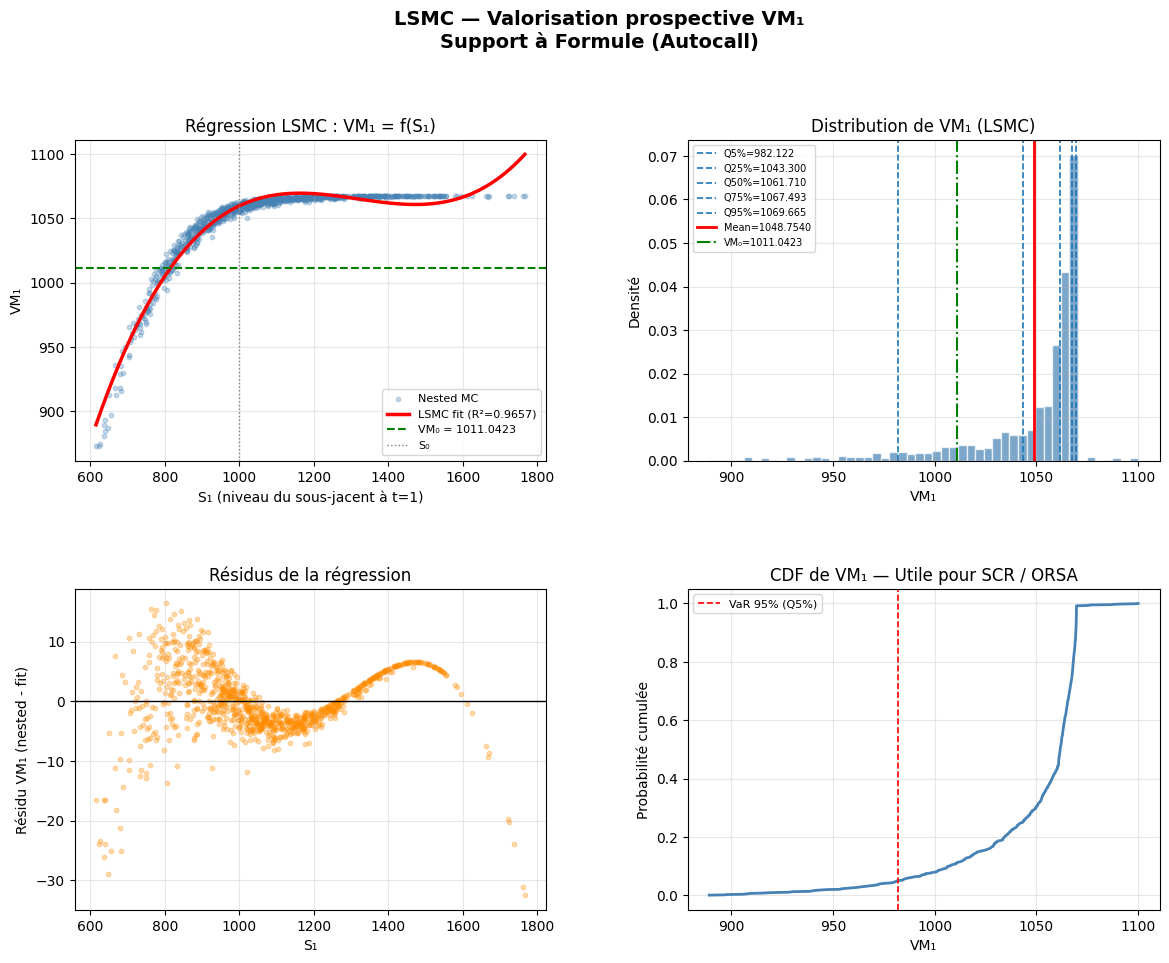

In [49]:
# ====================================================================
# 7. EXEMPLE D'UTILISATION COMPLET
# ====================================================================

if __name__ == "__main__":

    # --- Paramètres du produit (à adapter à votre SAF réel) ---
    params = SAFParams(
        s0=1000.0,                  # S0 = 100 (normalisé)
        capital=1000.0,             # nominal = 100
        coupon_rate=0.05,          # 7% par an par période
        barrier_autocall=0.75,     # autocall si S_t >= 100% de S0
        barrier_final=0.65,        # remboursement si S_T >= 80% de S0
        barrier_protection=0.50,   # protection si S_T >= 60% de S0
        autocall_dates_years=[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0],
        maturity_years=8.0,
        coupon_period=1.0,
    )

    # --- Paramètres de marché ---
    r =           # taux sans risque (3%)
    sigma = 0.20      # volatilité (20%)
    mu = 0.07         # drift physique (7%) pour les outer paths ORSA

    # --- VM₀ de référence ---
    print("Calcul VM₀...")
    vm0 = compute_vm0(params, r_annual_cc=r, sigma_annual=sigma, n_sims=50000)
    print(f"VM₀ = {vm0:.6f}\n")

    # --- LSMC pour VM₁ ---
    result = lsmc_vm1(
        params=params,
        r_annual_cc=r,
        sigma_annual=sigma,
        n_outer=1000,
        n_inner=1000,
        steps_per_year=12,
        poly_degree=3,
        mu_outer=mu,        # outer paths sous mesure physique P
        seed_outer=42,
        seed_inner=123,
        verbose=True,

    )

    # --- Visualisation ---
    plot_lsmc_results(result, params, vm0=vm0)

    # --- Résumé académique ---
    print("\n" + "=" * 60)
    print("RÉSUMÉ — Valorisation prospective LSMC")
    print("=" * 60)
    print(f"  VM₀                    = {vm0:.6f}")
    print(f"  VM₁ moyenne (LSMC)    = {result.vm1_mean:.6f}")
    print(f"  VM₁ écart-type        = {result.vm1_std:.6f}")
    print(f"  VM₁ Q5%  (VaR 95%)   = {result.vm1_quantiles['5%']:.6f}")
    print(f"  VM₁ médiane           = {result.vm1_quantiles['50%']:.6f}")
    print(f"  R² régression         = {result.r2_score:.6f}")
    print("=" * 60)

In [50]:
"""
====================================================================
LSMC — lsmc_vm1_single_product()
Valorisation prospective VM₁ d'un Support à Formule

À COLLER directement dans saf_model.py (après les fonctions VM et Payoff).

CONVENTION : on utilise s_ref (= 1000.0) comme unité de payoff,
             EXACTEMENT comme dans Payoff() du code original.
             Il n'y a PAS de paramètre "Capital" séparé.
====================================================================
"""

def lsmc_vm1_single_product(
    # ── Paramètres contractuels du produit ────────────────────────────
    # (interface identique à Payoff(), rien de plus)
    date_debut: str | pd.Timestamp,
    s_ref: float,                          # ex: 1000.0  → c'est le "Capital"
    barriere_sortie_anticipe: float,       # ex: 0.60
    barriere_sortie_maturite: float,       # ex: 0.60
    barriere_protection: float,            # ex: 0.50
    premiere_annee_sortie: int,            # ex: 5
    freq_sortie: FreqSortie,               # "annuelle" | "semestrielle" | ...
    coupon_par_periode: float,             # ex: 0.065
    annee_finale: int,                     # ex: 8
    # ── Paramètres de marché ──────────────────────────────────────────
    s0_t0: float,                          # niveau du sous-jacent à t=0
    r_neutre_cc: float,                    # taux sans risque (mesure Q)
    sigma_annual: float,                   # volatilité annuelle
    courbe_taux: pd.DataFrame,             # colonnes "Year" et "Taux"
    # ── Dates ─────────────────────────────────────────────────────────
    date_valuation_t0: str | pd.Timestamp, # date de valorisation initiale
    date_valuation_t1: str | pd.Timestamp, # date prospective (t0 + 1 an)
    # ── Paramètres LSMC ───────────────────────────────────────────────
    n_outer: int = 1000,                   # nb scénarios outer (P)
    n_inner: int = 1000,                   # nb inner paths par scénario (K)
    mu_outer: Optional[float] = None,      # drift outer (mesure P). None → utilise r
    poly_degree: int = 3,                  # degré polynôme de régression
    # ── Paramètres de simulation (identiques au code original) ────────
    decrement_value: float = 50.0,
    decrement_mode: DecrementMode = "cum",
    periods_per_year: int = 12,
    compounding: Compounding = "annual",
    day_count: int = 365,
    seed_outer: int = 42,
    seed_inner: int = 123,
    verbose: bool = True,
) -> dict:
    """
    LSMC — Estimation de la distribution de VM₁ pour un produit SAF.

    ================================================================
    ARCHITECTURE EN 4 ÉTAPES
    ================================================================

    ÉTAPE 1 — OUTER SIMULATION  (t₀ → t₁, mesure physique P)
    ----------------------------------------------------------
    On simule P trajectoires du sous-jacent sur 1 an :
      simulate_gbm_monthly(S0=s0_t0, drift=mu_outer, n_months≈12)
    → P valeurs S₁⁽ⁱ⁾ = niveau du sous-jacent à t₁ pour chaque scénario

    Pourquoi mesure P ?
      Dans le cadre ORSA / business planning, les outer paths représentent
      les états du monde réels possibles à t=1. On utilise donc le drift
      historique µ, pas le taux sans risque r.

    ÉTAPE 2 — INNER SIMULATION + NESTED MC  (t₁ → T, mesure Q)
    ------------------------------------------------------------
    Pour chaque S₁⁽ⁱ⁾ :
      a) simulate_gbm_monthly(S0=S₁⁽ⁱ⁾, drift=r, start=t₁, n_months=restant)
      b) decrement_paths(..., offset_periods=12)   ← continuer depuis t=1
      c) Payoff(inner_paths_dec, ...)              ← RÉUTILISE le code original
      d) VM(pay_tbl_i, date_valuation=t₁)         ← RÉUTILISE le code original
      → vm1_nested[i] = VM moyenne = nested estimate de E^Q[CF | S₁⁽ⁱ⁾]

    Pourquoi mesure Q pour les inner paths ?
      Les inner paths servent au PRICING (espérance actualisée des flux).
      En finance, le pricing se fait toujours sous la mesure risque-neutre Q.

    ÉTAPE 3 — RÉGRESSION LSMC (OLS polynomial)
    -------------------------------------------
    On approxime la fonction vm₁(S₁) par un polynôme :
      vm1_nested[i] ≈ β₀ + β₁·x + β₂·x² + ... + βₘ·xᵐ
    où x = S₁⁽ⁱ⁾ / s_ref  (normalisation pour stabilité numérique)

    Ajustement par moindres carrés ordinaires (np.linalg.lstsq).

    ÉTAPE 4 — PRÉDICTION
    --------------------
    vm1_lsmc[i] = f̂(S₁⁽ⁱ⁾ / s_ref)  pour tout i = 1,...,P

    ================================================================
    POINT CLÉ : offset_periods dans decrement_paths
    ================================================================
    Le décrement est cumulatif depuis t=0 (date_valuation_t0).
    Quand on simule les inner paths depuis t=1, il faut continuer
    le décompte, pas repartir de 0 :

      VM₀ outer paths  : offset_periods = 0
        → col 0 = 0, col 1 = 50/12, col k = k × 50/12

      VM₁ inner paths  : offset_periods = 12  (= 12 mois déjà écoulés)
        → col 0 = 12×50/12 = 50, col 1 = 13×50/12, ...

    Sans ce offset, les inner paths auraient un décrement erroné (reset à 0).

    ================================================================

    Parameters
    ----------
    date_debut : date d'émission contractuelle (ex: '2025-05-02')
    s_ref : niveau de référence des barrières ET unité de payoff (ex: 1000.0)
        → c'est le "Capital" du produit. Pas de paramètre Capital séparé.
    barriere_* : barrières en fraction de s_ref (ex: 0.60 = 60% de s_ref)
    s0_t0 : niveau du sous-jacent à date_valuation_t0 (ex: 1124.67)
    r_neutre_cc : taux sans risque annuel continu (mesure Q)
    sigma_annual : volatilité annuelle calibrée
    courbe_taux : DataFrame avec colonnes 'Year' et 'Taux'
    date_valuation_t0 : date de valorisation initiale (ex: '2025-12-31')
    date_valuation_t1 : date prospective = t0 + 1 an (ex: '2026-12-31')
    n_outer : nombre de scénarios outer P (recommandé ≥ 1000)
    n_inner : nombre de inner paths par scénario K (recommandé ≥ 500)
    mu_outer : drift annuel sous mesure physique pour outer paths.
               Si None → utilise r_neutre_cc (outer sous Q aussi)
    poly_degree : degré du polynôme de régression (3 recommandé)
    decrement_value : décrement annuel en points d'indice (ex: 50)
    decrement_mode : 'flat' ou 'cum'
    periods_per_year : 12 pour simulation mensuelle
    compounding : 'annual' ou 'cc' (doit correspondre à votre courbe des taux)
    day_count : 365 (convention du code original)
    seed_outer, seed_inner : graines pour reproductibilité

    Returns
    -------
    dict avec les clés :
      vm1_lsmc     : np.ndarray (n_outer,) — VM₁ LSMC par scénario
      vm1_nested   : np.ndarray (n_outer,) — nested MC avant régression
      s1_outer     : np.ndarray (n_outer,) — S₁ par scénario outer
      beta_coef    : np.ndarray — coefficients β de la régression
      r2           : float — R² de la régression
      vm1_mean     : float — VM₁ moyenne sur tous les scénarios
      vm1_std      : float — écart-type de VM₁
      vm1_quantiles: dict  — Q5%, Q25%, Q50%, Q75%, Q95%
    """
    # ── Conversions de dates ───────────────────────────────────────────
    date_valuation_t0 = pd.to_datetime(date_valuation_t0)
    date_valuation_t1 = pd.to_datetime(date_valuation_t1)
    date_debut_ts     = pd.to_datetime(date_debut)
    maturity_theo     = date_debut_ts + pd.DateOffset(years=annee_finale)

    # Drift outer : mesure physique si fourni, sinon mesure Q
    drift_outer = mu_outer if mu_outer is not None else r_neutre_cc

    if verbose:
        print("=" * 65)
        print("LSMC — Valorisation prospective VM₁")
        print("=" * 65)
        print(f"  date_debut = {date_debut_ts.date()}  |  maturité = {maturity_theo.date()}")
        print(f"  t₀ = {date_valuation_t0.date()}  |  S₀ = {s0_t0:.4f}  |  s_ref = {s_ref:.1f}")
        print(f"  t₁ = {date_valuation_t1.date()}")
        print(f"  Outer : P = {n_outer}, drift = {drift_outer:.4f} "
              f"({'mesure P' if mu_outer is not None else 'mesure Q'})")
        print(f"  Inner : K = {n_inner} par scénario, drift = {r_neutre_cc:.4f} (mesure Q)")
        print(f"  Régression : polynôme degré {poly_degree}")
        print()

    # ==================================================================
    # ÉTAPE 1 — OUTER SIMULATION  (t₀ → t₁)
    # ==================================================================
    if verbose:
        print("► Étape 1 : Simulation outer (t₀ → t₁)...")

    n_months_outer = _months_to_reach(date_valuation_t0, date_valuation_t1)

    outer_paths = simulate_gbm_monthly(
        s0          = s0_t0,
        r_annual_cc = drift_outer,       # drift physique ou Q selon mu_outer
        sigma_annual= sigma_annual,
        start_date  = str(date_valuation_t0.date()),
        n_months    = n_months_outer,
        n_sims      = n_outer,
        seed        = seed_outer,
    )

    # S₁⁽ⁱ⁾ = dernière colonne du DataFrame outer
    s1_outer = outer_paths.iloc[:, -1].values.astype(float)  # shape (n_outer,)

    if verbose:
        print(f"   S₁ : mean = {s1_outer.mean():.2f}  |  std = {s1_outer.std():.2f}"
              f"  |  min = {s1_outer.min():.2f}  |  max = {s1_outer.max():.2f}")
        print()

    # ==================================================================
    # ÉTAPE 2 — INNER SIMULATION + NESTED MC  (t₁ → T)
    # ==================================================================
    if verbose:
        print(f"► Étape 2 : Inner simulation + nested MC ({n_outer} × {n_inner})...")

    # Nombre de mois à simuler depuis t₁ jusqu'à la maturité
    n_months_inner = _months_to_reach(date_valuation_t1, maturity_theo)

    # Offset décrement : nombre de mois entre t₀ et t₁
    # (pour continuer le décrement cumulatif depuis t₀, pas repartir de 0)
    offset_at_t1 = int(round(
        (date_valuation_t1.year  - date_valuation_t0.year)  * 12
        + (date_valuation_t1.month - date_valuation_t0.month)
    ))

    rng_inner  = np.random.default_rng(seed_inner)
    vm1_nested = np.zeros(n_outer)

    for i in range(n_outer):

        # ── a) Simulation inner sous mesure Q ─────────────────────────
        inner_paths = simulate_gbm_monthly(
            s0          = float(s1_outer[i]),
            r_annual_cc = r_neutre_cc,           # TOUJOURS mesure Q ici
            sigma_annual= sigma_annual,
            start_date  = str(date_valuation_t1.date()),
            n_months    = int(n_months_inner),
            n_sims      = int(n_inner),
            seed        = int(rng_inner.integers(0, 2**31)),
        )

        # ── b) Décrement avec offset correct ──────────────────────────
        inner_paths_dec = decrement_paths(
            inner_paths,
            decrement_value  = float(decrement_value),
            periods_per_year = int(periods_per_year),
            mode             = decrement_mode,
            offset_periods   = offset_at_t1,   # ← continuer depuis t₁, pas reset à 0
        )

        # ── c) Payoff contractuel (réutilise EXACTEMENT le code original) ──
        pay_tbl_i = Payoff(
            paths                   = inner_paths_dec,
            date_debut              = date_debut_ts,
            s_ref                   = float(s_ref),
            barriere_sortie_anticipe= float(barriere_sortie_anticipe),
            barriere_sortie_maturite= float(barriere_sortie_maturite),
            barriere_protection     = float(barriere_protection),
            premiere_annee_sortie   = int(premiere_annee_sortie),
            freq_sortie             = freq_sortie,
            coupon_par_periode      = float(coupon_par_periode),
            annee_finale            = int(annee_finale),
            day_count               = int(day_count),
        )

        # ── d) VM à t₁ (réutilise EXACTEMENT le code original) ────────
        _, vm_i = VM(
            payoff_table   = pay_tbl_i,
            courbe_taux    = courbe_taux,
            date_valuation = date_valuation_t1,
            col_year       = "Year",
            col_taux       = "Taux",
            compounding    = compounding,
            day_count      = day_count,
        )

        vm1_nested[i] = vm_i

        if verbose and (i + 1) % max(1, n_outer // 5) == 0:
            print(f"   {i+1:>5}/{n_outer}  |  VM₁ nested running mean = {vm1_nested[:i+1].mean():.4f}")

    if verbose:
        print(f"\n   VM₁ nested : mean = {vm1_nested.mean():.4f}  |  std = {vm1_nested.std():.4f}")
        print()

    # ==================================================================
    # ÉTAPE 3 — RÉGRESSION LSMC (OLS polynomial)
    # ==================================================================
    if verbose:
        print(f"► Étape 3 : Régression polynomiale (degré {poly_degree})...")

    # Variable explicative normalisée : x = S₁ / s_ref
    # → même normalisation que les barrières dans Payoff()
    x = s1_outer / float(s_ref)

    # Matrice de Vandermonde : colonnes = [1, x, x², ..., xᵐ]
    X_poly = np.column_stack([x ** k for k in range(poly_degree + 1)])

    # OLS par numpy.linalg.lstsq (stable, pas de dépendance sklearn)
    beta, _, _, _ = np.linalg.lstsq(X_poly, vm1_nested, rcond=None)

    vm1_fitted = X_poly @ beta

    # R² de la régression
    ss_res = np.sum((vm1_nested - vm1_fitted) ** 2)
    ss_tot = np.sum((vm1_nested - vm1_nested.mean()) ** 2)
    r2 = float(1.0 - ss_res / ss_tot) if ss_tot > 0 else 0.0

    if verbose:
        print(f"   Coefficients β : {np.round(beta, 4)}")
        print(f"   R²             : {r2:.6f}")
        print()

    # ==================================================================
    # ÉTAPE 4 — PRÉDICTION LSMC
    # ==================================================================
    # Prédiction sur les mêmes outer scenarios
    vm1_lsmc = np.maximum(vm1_fitted, 0.0)   # non-négativité économique

    quantiles = {
        "5%":  float(np.percentile(vm1_lsmc, 5)),
        "25%": float(np.percentile(vm1_lsmc, 25)),
        "50%": float(np.percentile(vm1_lsmc, 50)),
        "75%": float(np.percentile(vm1_lsmc, 75)),
        "95%": float(np.percentile(vm1_lsmc, 95)),
    }

    if verbose:
        print("► Résumé VM₁ LSMC :")
        print(f"   mean   = {vm1_lsmc.mean():.4f}  |  std = {vm1_lsmc.std():.4f}")
        print(f"   Q5%    = {quantiles['5%']:.4f}")
        print(f"   médiane= {quantiles['50%']:.4f}")
        print(f"   Q95%   = {quantiles['95%']:.4f}")
        print("=" * 65)

    return {
        "vm1_lsmc"    : vm1_lsmc,       # np.ndarray (n_outer,) — VM₁ finale
        "vm1_nested"  : vm1_nested,     # np.ndarray (n_outer,) — avant régression
        "s1_outer"    : s1_outer,       # np.ndarray (n_outer,) — S₁ par scénario
        "beta_coef"   : beta,           # coefficients OLS
        "r2"          : r2,
        "vm1_mean"    : float(vm1_lsmc.mean()),
        "vm1_std"     : float(vm1_lsmc.std()),
        "vm1_quantiles": quantiles,
        # métadonnées utiles pour le mémoire
        "poly_degree" : poly_degree,
        "s_ref"       : float(s_ref),
        "n_outer"     : n_outer,
        "n_inner"     : n_inner,
        "date_valuation_t1": date_valuation_t1,
    }